# Valve Position Prediction Project
This project is aimed at using the behaviour of a `PID regulator` based control system obtained from `Matlab`
to predict the opening level of the actuating mechanism (i.e. the valve) through various regressors such as `RandomForestRegressor` and `CatBoostRegressor`.
## 1. Problem definition
> How well can a valve's position be predicted using the data obtained from a Matlab simulation of a PID based control system
## 2. Data
> We have data from Matlab-Simulink based models of a PID based liquid level control system at `training_data_from_matlab2.csv`
* The dataset has timestamps in `seconds` format.
* It has the desired input levels of the liquid in meters.
* The output liquid levels in meters as well
* The feedback: The difference the desired output (input) and the actual output.
* Opening levels of the valve in % (0-100)
### 2.1. How to format the data
* We need to check what kind of format, the data under label `Time` are in and then convert them into either datetime.seconds or int64 format
* Convert `string` datatypes to float using `pd.to_numeric(downcast = 'float')`
* Eliminate any missing data by first generating `is_missing` boolean data for each column of the input data
* Then eliminate by checking through `isna().sum()` and `_is_missing.value_counts()` and then eliminating the missing values by replacing them with `medians`
* Eliminate erronious data. I.e. liquid levels above `1.0` in `input` and `liquid_level` columns and valve opening levels above `100` in `valve_positions` by replacing them with medians.
## 3. Modelling
* Use `train_test_split()` from `sklearn` to divide the dataset into training and validation datasets.
* Use `RandomForestRegressor` to train the model using the training dataset.
* Use `CatBoostRegressor` to train the model using the training dataset.
* Use `RandomizedSearchCV` to get the optimize the model using the best hyperparameters `RandomForestRegressor`
* Use `catboostcv` to obtain best hyperparameters for `CatBoostRegressor`
* Evaluate the optimized model on the validation datasets.
* Use test datasets to check the predictions of the model against true labels.
## 4. Saving the model for export and reuse
At this step, we will save the model. 
* Use the `pickle` module to save the models
* Or the `joblib` module to save the models.
  
## 5. Applying the output of the model on the transfer function of the control object
* This purpose can be achieved using the `control` library.
* Use the `control` library to simulate the output liquid level due to the valve opening levels predicted by the models in step 3. 



## 2. Data preparation
* In this part, we are going to import `training_data_from_matlab6.csv`.
* Check out what kind of format, the `Time` data is in and convert it into either int64 or `datetime(format = "seconds")`
* After that, we are to check for any other `string` type data using `pd.api.dtypes.is_string_dtype()` function. And convert all string type data to numeric, using`pd.to_numeric(downcast='float')`
* After converting all of the content of the dataframe except for *DateTime* we will check for missing data using `pd.isnull()`
* If found, then the missing data is to be replaced by zero.
* Once missing data is filled, we will be checking for values more than 100 in `Valve_positions` and values more than 1000 in `Liquid_levels`.
* This is errroneous data and it is to be replaced by the median values of the above mentioned labels.
* We will make a copy of the preprocessecd dataframe and label it as `df_for_modelling`
* In `df_for_modelling`, we will extract the year, month, date, hour, minute and seconds data from the DateTime column and then drop the datetime column as it can't be used for training a Regressor model.
* We are ready for modelling!

### Importing the libraries

In [1]:
# Import the required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import control as ct
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from catboost import CatBoostRegressor
import pickle
from joblib import load, dump
%matplotlib inline

### Importing the data and modifying it for fitting into a Regression model

In [2]:
df_raw_2 = pd.read_csv("training_data_from_matlab6.csv", low_memory=False)
# Make a copy of the raw dataframe before going on with something else
df_modified_data = df_raw_2.copy()
df_modified_data.info()
df_modified_data.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25853 entries, 0 to 25852
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Time             25853 non-null  object 
 1   Input            25853 non-null  float64
 2   Liquid_levels    25853 non-null  float64
 3   Feedback         25853 non-null  float64
 4   Valve_Positions  25853 non-null  float64
dtypes: float64(4), object(1)
memory usage: 1010.0+ KB


,Time,Input,Liquid_levels,Feedback,Valve_Positions
0,0 sec,0.0,0.000000e+00,0.000000,0.000000
1,250 sec,0.0,0.000000e+00,0.000000,0.000000
2,250 sec,0.8,0.000000e+00,0.800000,66.417308
3,250 sec,0.8,1.394661e-13,0.800000,66.417308
4,252.34 sec,0.8,1.860182e-01,0.613982,82.258628


In [3]:
# Let's try converting this Time column to datetime/timedelta
df_modified_data["Time"] = df_modified_data["Time"].str.replace(" sec", "", regex=True)


In [4]:
# Now that the data under the column "Time" can now probably be converted to numeric dtypes
df_modified_data["Time"] = pd.to_numeric(df_modified_data["Time"])

In [5]:
df_modified_data["TimeDelta"] = pd.to_timedelta(df_modified_data.Time, unit = 's')

In [6]:
df_modified_data.head()

,Time,Input,Liquid_levels,Feedback,Valve_Positions,TimeDelta
0,0.00,0.0,0.000000e+00,0.000000,0.000000,0 days 00:00:00
1,250.00,0.0,0.000000e+00,0.000000,0.000000,0 days 00:04:10
2,250.00,0.8,0.000000e+00,0.800000,66.417308,0 days 00:04:10
3,250.00,0.8,1.394661e-13,0.800000,66.417308,0 days 00:04:10
4,252.34,0.8,1.860182e-01,0.613982,82.258628,0 days 00:04:12.340000


In [7]:
df_modified_2 = df_modified_data.copy()

In [8]:
df_modified_2.drop("TimeDelta", axis = 1, inplace = True)

In [9]:
df_modified_2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25853 entries, 0 to 25852
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Time             25853 non-null  float64
 1   Input            25853 non-null  float64
 2   Liquid_levels    25853 non-null  float64
 3   Feedback         25853 non-null  float64
 4   Valve_Positions  25853 non-null  float64
dtypes: float64(5)
memory usage: 1010.0 KB


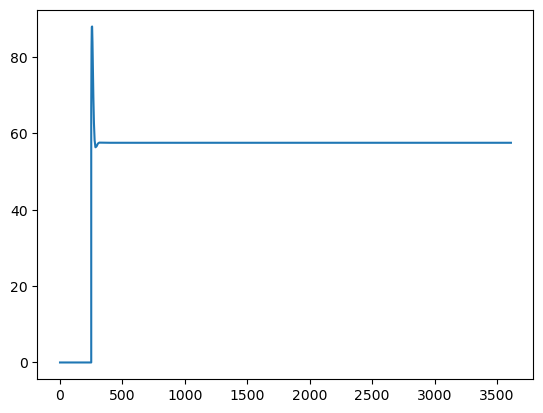

In [10]:
fig, ax = plt.subplots()
ax.plot(df_modified_2.Time[:300], df_modified_2.Valve_Positions[:300]);

In [11]:
# We know that all of these are numeric dtypes but still we will check for any string dtype remaining
for label, content in df_modified_2.items():
    if pd.api.types.is_string_dtype(content):
        print("There are string types in: ", label)
    else:
        print("There are no strings in :", label)

There are no strings in : Time
There are no strings in : Input
There are no strings in : Liquid_levels
There are no strings in : Feedback
There are no strings in : Valve_Positions


In [12]:
# Check for invalid/empty data
for label, content in df_modified_2.items():
    if pd.api.types.is_numeric_dtype(content):
        if pd.isnull(content).sum():
            print("There are NaNs in: ", label)
            df_modified_2[label + "is_missing"] = pd.isnull(content)
            df_modified_2[label] = content.fillna(0)
        else:
            print("There are no missing values in: ", label)
        

There are no missing values in:  Time
There are no missing values in:  Input
There are no missing values in:  Liquid_levels
There are no missing values in:  Feedback
There are no missing values in:  Valve_Positions


In [13]:
# Check for erroneous data in Liquid_levels
for content in df_modified_2.Liquid_levels:
    if (content > 1.25):
        print("Erroneous value found! ", content)
        content = df_modified_2.Liquid_levels.median()

# Check for erroneous data in Valve_positions
for content in df_modified_2.Valve_Positions:
    if (content > 100.0):
        print("Erroneous data found! ", content)
        content = df_modified_2.Valve_Positions.median()
np.max(df_modified_2.Liquid_levels), np.max(df_modified_2.Valve_Positions)    

(0.862643337266345, 88.0234256553024)

## 3. Modelling
* At this stage, a model based on `RandomForestRegressor` is to be created
* Next, the target variable will be separated from the others to create `X` and `y` datasets
* Here, the `Valve_Positions` column of our dataset is the target variable, to be predicted. It will be placed in the dataframe `y`
* All the other variables i.e. `Time`, `Input`, `Liquid_levels` and `Feedback` will be placed in `X`
* Next, X and y will be divided into training and validation sets using `train_test_split`
* After that the model will be fitted with `X_train and y_train`, its effectiveness will be checked with the validation datasets
* The model will then be optimized using `RandomizedSearchCV` to see if its effectiveness can be improved upon. 

In [14]:
# We are prepared for modelling
X = df_modified_2.drop("Valve_Positions", axis = 1)
y = df_modified_2["Valve_Positions"]
X_train, X_val, y_train, y_val = train_test_split(X,y,
                                                      test_size=0.2)
model = RandomForestRegressor(n_jobs = -1,
                              random_state=45)

In [15]:
%%time
# let's try fittig once more
model.fit(X_train, y_train)

CPU times: total: 2.53 s
Wall time: 214 ms


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [16]:
val_preds = model.predict(X_val)


In [17]:
model.score(X_val, y_val)

0.2827077720342063

In [18]:
model.score(X_train, y_train)

0.8891507093723011

### Optimization of the model using RandomizedSearch CV
In this step, we will be using `RandomizedSearchCV` to optimize the hyperparameters of the model


In [19]:
%%time
from sklearn.model_selection import RandomizedSearchCV
# Define the rf_grid
rf_grid = {"n_estimators": np.arange(0, 1500, 10),
           "criterion": ["squared_error", "absolute_error", "poisson", "friedman_mse"],
           "max_depth": [None, 3, 5, 10, 15, 20],
           "min_samples_split": np.arange(2, 60, 2),
           "min_samples_leaf": np.arange(1, 30, 2),
           "max_features": [ 0.25, 0.5, 1.0, 'sqrt'],
           "max_samples": [None]}
# Create the optimized model
rs_model = RandomizedSearchCV(RandomForestRegressor(n_jobs=-1,
                                                    random_state=45),
                               param_distributions = rf_grid,
                              n_iter = 6, 
                              cv = 5,
                              verbose = True)
# Fit the model
rs_model.fit(X_train, y_train)

Fitting 5 folds for each of 6 candidates, totalling 30 fits
CPU times: total: 9min 44s
Wall time: 1min 2s


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestR...ndom_state=45)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'criterion': ['squared_error', 'absolute_error', ...], 'max_depth': [None, 3, ...], 'max_features': [0.25, 0.5, ...], 'max_samples': [None], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",6
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be

In [20]:
rs_model.best_params_

{'n_estimators': 780,
 'min_samples_split': 6,
 'min_samples_leaf': 3,
 'max_samples': None,
 'max_features': 1.0,
 'max_depth': 3,
 'criterion': 'absolute_error'}

In [21]:
rs_model.score(X_val, y_val)

-0.05067415234676331

### Preparation of a function to preprocess data
* We will train the model on the entire dataset
* We will be able to train the model on timestamps
* To make the preprocessing easier, we will develop a preprocessing function


In [22]:
# Develop a file path
FILE_PATH = "training_data_from_matlab5.csv"

def preprocess_data(PROVIDED_FILE_PATH):
    """
    This function is meant to predict the opening level of a valve on the basis of input data, feedback data and timestamps
    The data is to be imported from the datasheets as specified in "FILE_PATH"
    The file will imported to a pandas dataframe
    The time data is to be converted from string to numeric
    A check will be performed to remove string type data, which is to be converted to float type
    Then a check will be performed for any missing data
    Then erroneous data (liquid levels > 1.2 and valve positions > 100) will be replaced with the median values of the respective columns
    The dataframe will be ready for further action!
    """
    # Step-1 read data from the file path
    print("Reading data....")
    df_data = pd.read_csv(PROVIDED_FILE_PATH)
    # Step-2 change the datatype of time column from string to numeric
    # In this case, we need to remove the phrase 'sec' from the column
    print("Changing the Time data from string to numeric....")
    df_data["Time"] = df_data["Time"].str.replace(" sec","",regex=True)
    # Then we will have to change the datatype from object to numeric
    df_data["Time"] = pd.to_numeric(df_data["Time"])
    # Step-3: Check for string type data
    print("Checking for string type data....")
    for label, content in df_data.items():
        if pd.api.types.is_string_dtype(content):
            print("There is string type data in: ",label)
            print("Converting strings to float in: ", label)
            df_data[label] = pd.to_numeric(df_data[label],errors = "coerce")
        else:
            print("There are no strings in: ", label)
    # Step-4: Check for missing data
    print("Checking for missing data....")
    for label, content in df_data.items():
        if pd.api.types.is_numeric_dtype(content):
            if pd.isnull(content).sum():
                print("There are missing values in: ", label)
                df_data[label + "is_missing"] = pd.isnull(content)
                # Now fill the missing data with zeroes
                df_data[label] = content.fillna(0)
            else:
                print("There are no missing values in: ",label)
    # Step-5: Now check for erroneous data
    print("Checking for erroneous data....")
    # In this case first we will be removing any values 
    for content in df_data["Liquid_levels"]:
        if (content > 1.5):
            print("Erroneous data found")
            content = df_data["Liquid_levels"].median()
    for content in df_data["Valve_Positions"]:
        if (content > 100.0):
            print("Erroneous data found")
            content = df_data["Valve_Positions"].median()


    
    print("Preprocessing complete....")
    print(df_data.info())
    return df_data
            

In [23]:
df_data2=preprocess_data(FILE_PATH)

Reading data....
Changing the Time data from string to numeric....
Checking for string type data....
There are no strings in:  Time
There are no strings in:  Input
There are no strings in:  Liquid_levels
There are no strings in:  Feedback
There are no strings in:  Valve_Positions
Checking for missing data....
There are no missing values in:  Time
There are no missing values in:  Input
There are no missing values in:  Liquid_levels
There are no missing values in:  Feedback
There are no missing values in:  Valve_Positions
Checking for erroneous data....
Preprocessing complete....
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9021 entries, 0 to 9020
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Time             9021 non-null   float64
 1   Input            9021 non-null   float64
 2   Liquid_levels    9021 non-null   float64
 3   Feedback         9021 non-null   float64
 4   Valve_Positions  9021 non-nu

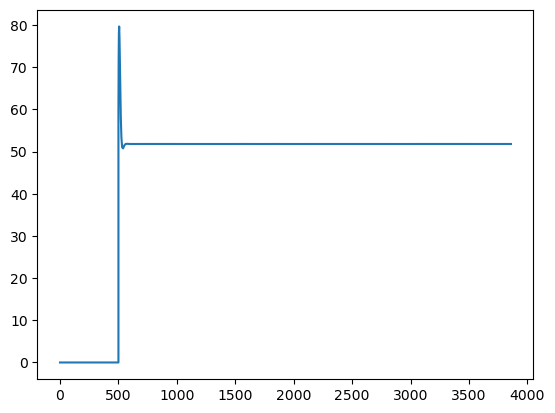

In [24]:
fig, ax = plt.subplots()
ax.plot(df_data2.Time[:300], df_data2.Valve_Positions[:300]);

In [25]:
# Create a test data set
X_test = df_data2.drop("Valve_Positions", axis=1)
X_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9021 entries, 0 to 9020
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Time           9021 non-null   float64
 1   Input          9021 non-null   float64
 2   Liquid_levels  9021 non-null   float64
 3   Feedback       9021 non-null   float64
dtypes: float64(4)
memory usage: 282.0 KB


In [26]:
y_preds = model.predict(X_test)

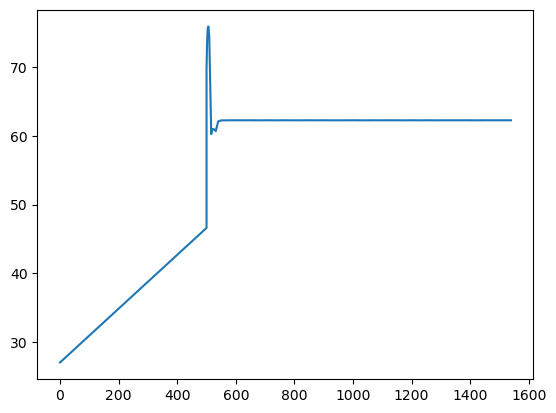

In [27]:
fig, ax = plt.subplots()
ax.plot(df_data2.Time[:100], y_preds[:100]);

In [28]:
y_true = df_data2["Valve_Positions"]

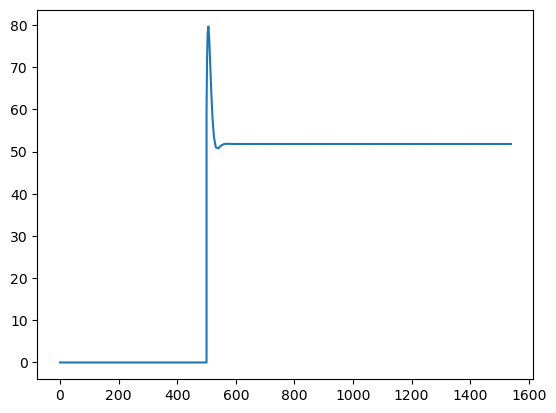

In [29]:
fig, ax = plt.subplots()
ax.plot(df_data2.Time[:100], y_true[:100]);

In [30]:
# Let's try using the rs_model too and see how it performs
y_preds_rs = rs_model.predict(X_test)

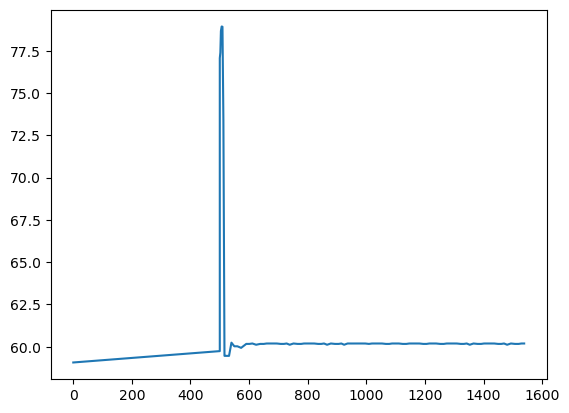

In [31]:
# Plot the output of rs_model
fig,ax = plt.subplots()
ax.plot(df_data2.Time[:100], y_preds_rs[:100]);

## 4. Saving the model for further use and exporting 
The initial and the RandomizedSearchCV based model will be saved using both `pickle` and `joblib` libraries

In [32]:

# Save an existing model to file
# pickle.dump(model, open("rf_regressor_valve_position_predictor_6.pkl", "wb"))


In [33]:
# Lets try to see if our loaded model worked or not
loaded_pickle_model_6 = pickle.load(open("rf_regressor_valve_position_predictor_6.pkl","rb"))

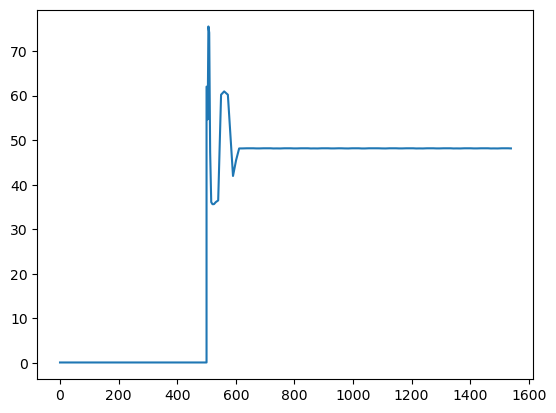

In [34]:
pickle_y_preds = loaded_pickle_model_6.predict(X_test)
fig, ax = plt.subplots()
ax.plot(df_data2.Time[:100], pickle_y_preds[:100]);

In [35]:
# Let's save the RandomizedSearchCV model with joblib

# Save the rs optimized model to a file
# dump(rs_model, filename="rs_optimized_valve_position_predictor_1.joblib")

C:\Users\anshu\anaconda3\Lib\site-packages\sklearn\base.py:463: InconsistentVersionWarning: Trying to unpickle estimator DecisionTreeRegressor from version 1.7.2 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
C:\Users\anshu\anaconda3\Lib\site-packages\sklearn\base.py:463: InconsistentVersionWarning: Trying to unpickle estimator RandomForestRegressor from version 1.7.2 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
C:\Users\anshu\anaconda3\Lib\site-packages\sklearn\base.py:463: InconsistentVersionWarning: Trying to unpickle estimator RandomizedSearchCV from version 1.7.2 when using version 1.8.0. This migh

0.7740552853327138


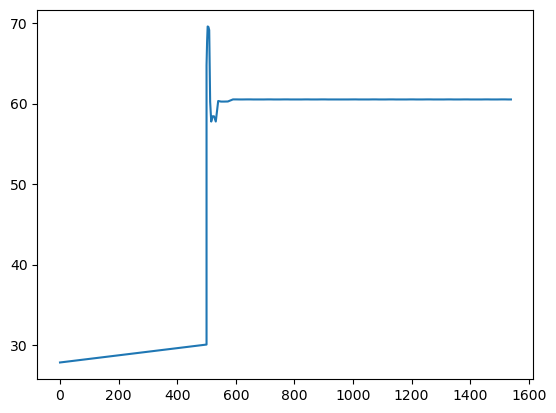

In [36]:
# Import a saved joblib model
loaded_rs_model = load(filename="rs_optimized_valve_position_predictor_1.joblib")
print(loaded_rs_model.score(X_val, y_val))
loaded_rs_y_preds = loaded_rs_model.predict(X_test)
fig, ax = plt.subplots()
ax.plot(df_data2.Time[:100], loaded_rs_y_preds[:100]);

## 5. Applying the output of the model on the transfer function of the control object

In [37]:
# Lets try to use the control library
# The transfer function of the control object is 1.23/12.04S+1
# Numerator is [1.23], denominator is [12.04,1]
num = [1.23]
den = [12.04,1]
W_object = ct.tf(num,den)
W_object

TransferFunction(array([1.23]), array([12.04,  1.  ]))

In [38]:
 # let's try to plot the forced response
time_vector = np.linspace(0, 10500, df_data2.Time.size)
time_returned2, sysout = ct.forced_response(0.0113*W_object, time_vector, pickle_y_preds)
time_returned3, sysout2 = ct.forced_response(0.0113*W_object, time_vector, y_true)

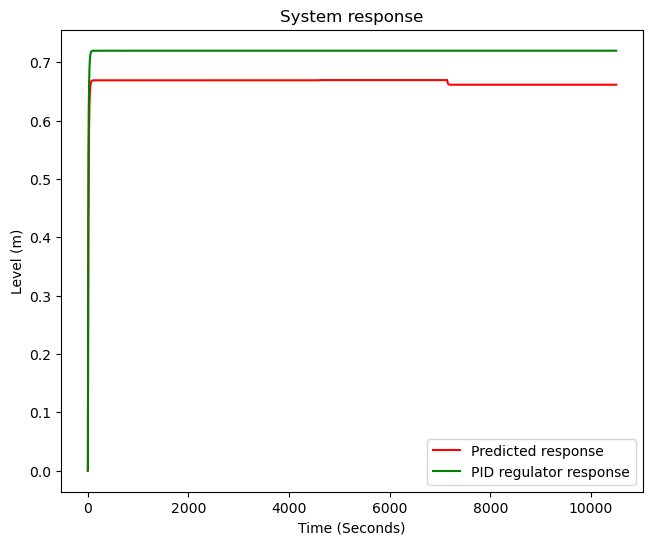

In [39]:
fig, ax2 = plt.subplots(figsize=(7.5,6))
ax2.plot(time_returned2,
        sysout, c = 'r', label = "Predicted response")
ax2.plot(time_returned2, sysout2, c = 'g', label = "PID regulator response")
ax2.set(title="System response",
        xlabel="Time (Seconds)",
        ylabel="Level (m)")
ax2.legend();


In [40]:
from sklearn.metrics import mean_absolute_error
mean_absolute_error(sysout2, sysout)

0.053090386157031745

In [41]:
((mean_absolute_error(sysout2, sysout))/0.75)*100

7.0787181542708995

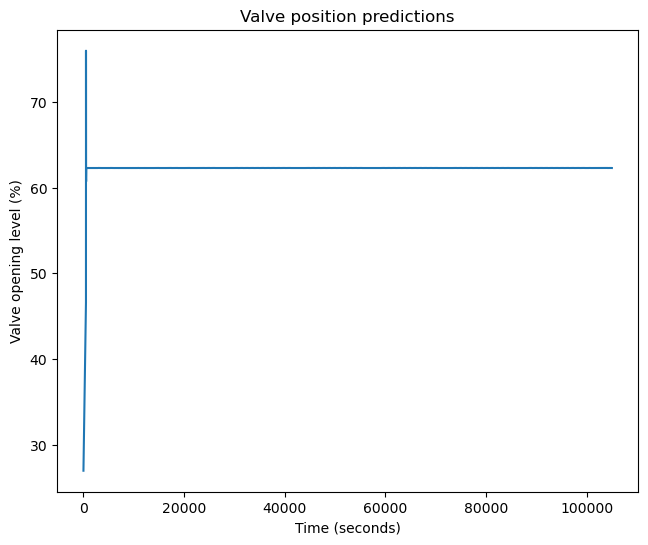

In [42]:
fig, ax3 = plt.subplots(figsize=(7.5,6))
ax3.plot(df_data2.Time, y_preds)
ax3.set(xlabel = "Time (seconds)",
        ylabel = "Valve opening level (%)",
        title = "Valve position predictions");

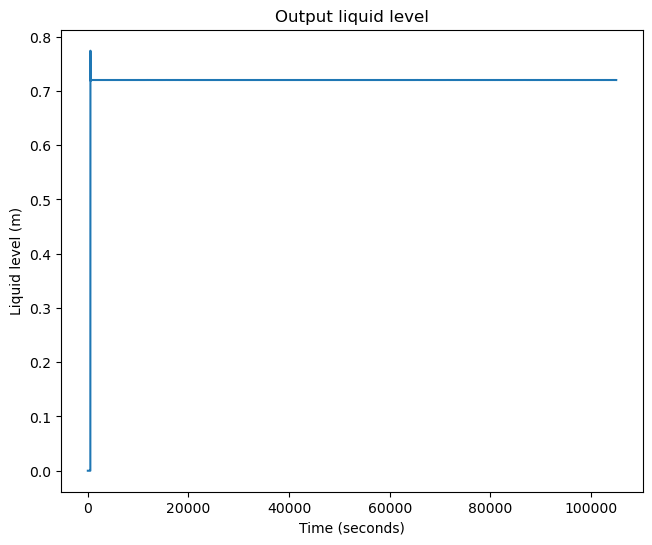

In [43]:
fig, ax4 = plt.subplots(figsize=(7.5,6))
ax4.plot(df_data2.Time, df_data2.Liquid_levels)
ax4.set(xlabel = "Time (seconds)",
        ylabel = "Liquid level (m)",
        title = "Output liquid level");

## 6. Improvisation: 

In order to improvise the model, we can take the following steps: 
1. Use a larger dataset to train the model.  
2. Use a different machine learning regressor (In this case, we will be trying out `catboost_regressor`)

### 6.1. Improvisation using a larger dataset

A dataset with larger number of samples has been prepared at `training_data_from_matlab7.csv`. 
* The function `preprocess_data()` is to be used to preprocess the data.
* Then a `RandomForestRegressor` based model will be trained on the preprocessed data
* Next, the preprocessing function is to be used once again to preprocess validation data at `training_data_from_matlab_8.csv`
* The model is to be tested on this validation data

In [44]:
# Use the preprocess data function to preprocess the data from training_data_from_matlab7.csv
FILE_PATH_2 = "training_data_from_matlab7.csv"
df_data3 = preprocess_data(FILE_PATH_2)

Reading data....
Changing the Time data from string to numeric....
Checking for string type data....
There are no strings in:  Time
There are no strings in:  Input
There are no strings in:  Liquid_levels
There are no strings in:  Feedback
There are no strings in:  Valve_Positions
Checking for missing data....
There are no missing values in:  Time
There are no missing values in:  Input
There are no missing values in:  Liquid_levels
There are no missing values in:  Feedback
There are no missing values in:  Valve_Positions
Checking for erroneous data....
Preprocessing complete....
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25474 entries, 0 to 25473
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Time             25474 non-null  float64
 1   Input            25474 non-null  float64
 2   Liquid_levels    25474 non-null  float64
 3   Feedback         25474 non-null  float64
 4   Valve_Positions  25474 non

In [45]:
def prepare_for_modelling(DataFrame):
    """
    Function to prepare the data for fitting into the model
    Takes a dataframe as input. Drops the Valve_positions data for X and Valve_positions data is used as y
    X and y are returned
    """
    X = DataFrame.drop("Valve_Positions", axis = 1)
    y = DataFrame["Valve_Positions"]
    return X,y

In [46]:
X2,y2 = prepare_for_modelling(df_data3)

In [47]:
# Split the data into training and validation sets
X2_train, X2_val,y2_train, y2_val = train_test_split(X2, y2, test_size = 0.25) 

In [48]:
# Prepare the model
model_2 = RandomForestRegressor(n_jobs=-1,
                                criterion = "absolute_error",
                                random_state=45)

In [49]:
%%time 
# Fit the model
model_2.fit(X2_train, y2_train)

CPU times: total: 17.2 s
Wall time: 1.21 s


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'absolute_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsampl

In [50]:
# Try to evaluate the model
model_2.score(X2_val, y2_val)

0.9993597834196468

Now let's test the model on a test data set
* In order to test the model, a test data set is present at `training_data_from_matlab8.csv`
* Preprocess that data to a new dataframe
* Have the model predict on the data and evaluate the predictions against the true labels


In [51]:
# preprocess the test data set
FILE_PATH_3 = "training_data_from_matlab5.csv"
df_test_data_2 = preprocess_data(FILE_PATH_3)

Reading data....
Changing the Time data from string to numeric....
Checking for string type data....
There are no strings in:  Time
There are no strings in:  Input
There are no strings in:  Liquid_levels
There are no strings in:  Feedback
There are no strings in:  Valve_Positions
Checking for missing data....
There are no missing values in:  Time
There are no missing values in:  Input
There are no missing values in:  Liquid_levels
There are no missing values in:  Feedback
There are no missing values in:  Valve_Positions
Checking for erroneous data....
Preprocessing complete....
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9021 entries, 0 to 9020
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Time             9021 non-null   float64
 1   Input            9021 non-null   float64
 2   Liquid_levels    9021 non-null   float64
 3   Feedback         9021 non-null   float64
 4   Valve_Positions  9021 non-nu

In [52]:
X2_test, y2_test = prepare_for_modelling(df_test_data_2)

In [53]:
X2_test.head()

,Time,Input,Liquid_levels,Feedback
0,0.00,0.00,0.000000e+00,0.000000
1,500.00,0.00,0.000000e+00,0.000000
2,500.00,0.72,0.000000e+00,0.720000
3,500.00,0.72,2.510389e-13,0.720000
4,501.91,0.72,1.363256e-01,0.583674


In [54]:
%%time
# Now that the test data is prepared, get the model to predict on the test data
y2_preds = model_2.predict(X2_test)

CPU times: total: 46.9 ms
Wall time: 26 ms


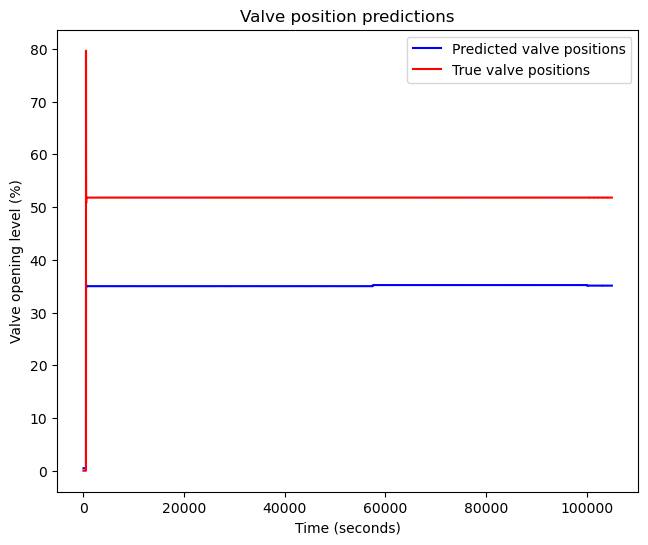

In [55]:
fig, ax8 = plt.subplots(figsize=(7.5,6))
ax8.plot(df_test_data_2.Time, y2_preds, c = "blue", label = "Predicted valve positions")
ax8.plot(df_test_data_2.Time, y2_test, c = "red", label = "True valve positions")
ax8.set(xlabel = "Time (seconds)",
        ylabel = "Valve opening level (%)",
        title = "Valve position predictions")
ax8.legend();

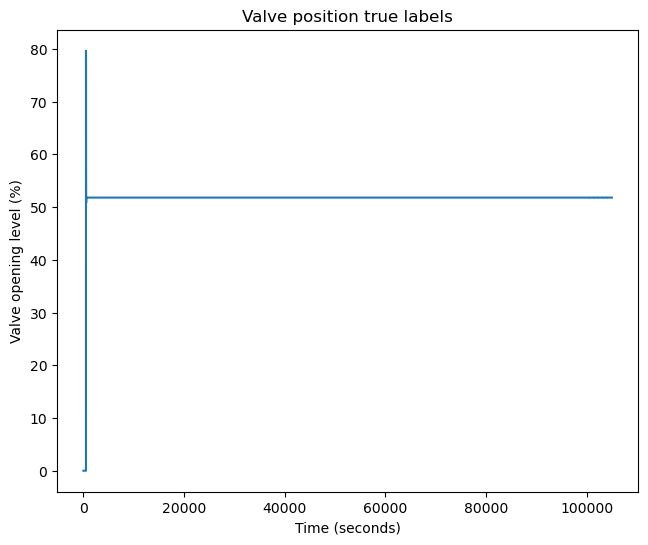

In [56]:
fig, ax9 = plt.subplots(figsize=(7.5,6))
ax9.plot(df_test_data_2.Time, y2_test)
ax9.set(xlabel = "Time (seconds)",
        ylabel = "Valve opening level (%)",
        title = "Valve position true labels");

In [57]:
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, mean_squared_error

In [58]:
mean_absolute_error(y2_test, y2_preds) 

16.72053231639896

In [59]:
mean_squared_error(y2_test, y2_preds)

280.0020684251141

In [60]:
# Try to plot the output of the transfer function
num = [1.76]
den = [14.39,1]
W_object_2 = ct.tf(num,den)
W_object_2

TransferFunction(array([1.76]), array([14.39,  1.  ]))

In [61]:
# Try to plot the response for the liquid 

In [62]:
time_vector = np.linspace(0, 20376, df_test_data_2.Time.size)
time_returned3, sysout2 = ct.forced_response(0.0113*W_object, time_vector, y2_preds) # Predicted liquid levels as per transfer function
time_returned4, sysout3 = ct.forced_response(0.0113*W_object, time_vector, y2_test)

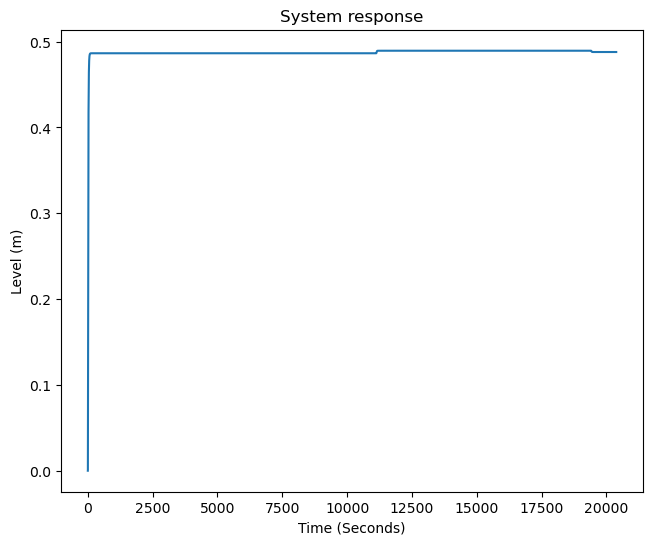

In [63]:
fig, ax10 = plt.subplots(figsize=(7.5,6))
ax10.plot(time_returned3,
        sysout2)

ax10.set(title="System response",
        xlabel="Time (Seconds)",
        ylabel="Level (m)");

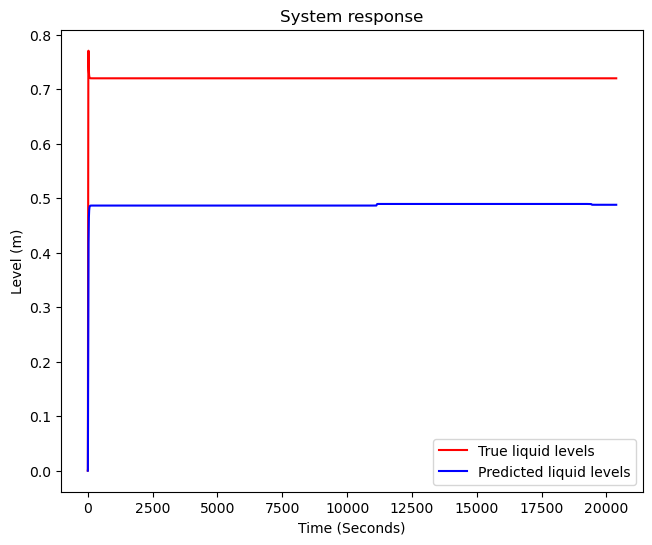

In [64]:
fig, ax11 = plt.subplots(figsize=(7.5, 6))
ax11.plot(time_returned4, sysout3, color = 'r', label = "True liquid levels")
ax11.plot(time_returned3, sysout2, color = 'b', label = "Predicted liquid levels")
ax11.set(title="System response",
        xlabel="Time (Seconds)",
        ylabel="Level (m)")
ax11.legend();

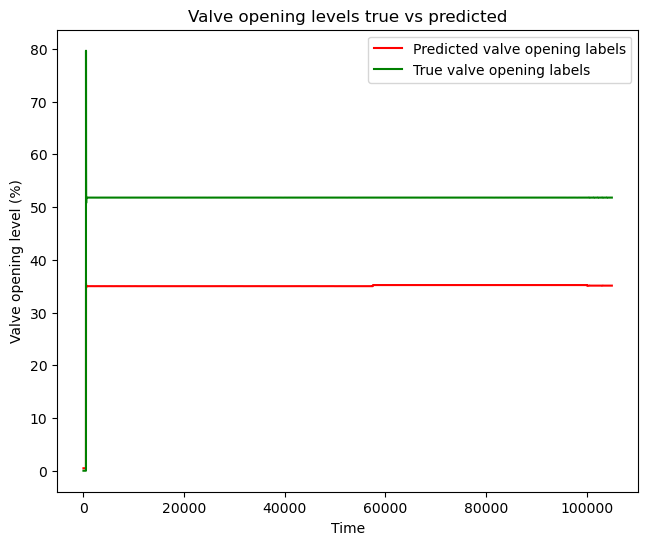

In [65]:
# Superimpose the predicted valve_opening levels upon the true labels
fig, ax12 = plt.subplots(figsize =  (7.5,6))
ax12.plot(df_test_data_2.Time, y2_preds, color = 'r', label = "Predicted valve opening labels")
ax12.plot(df_test_data_2.Time, y2_test, color = 'g', label = "True valve opening labels")
ax12.set(xlabel = "Time",
         ylabel = "Valve opening level (%)",
         title = "Valve opening levels true vs predicted")
ax12.legend();
                         

Obtaining `feature_importance` for `model_2`
Create a function to plot the feature importances of the model, predicting valve position for liquid leel control system

In [66]:
def plot_feature_importances(model):
    """
    Create a small dataframe providing the feature importances of the various features in the features dataframe of a model.
    Takes the model and features dataframe as input.
    """
    df_feature_importances = pd.DataFrame(model.feature_importances_, index=["Time", "Input", "Liquid_levels", "Feedback"])
    return df_feature_importances

In [67]:
model_2.feature_importances_

array([0.14072867, 0.85620647, 0.00159143, 0.00147343])

In [68]:
X2.columns

Index(['Time', 'Input', 'Liquid_levels', 'Feedback'], dtype='object')

In [69]:
model_2_feature_importances = plot_feature_importances(model_2)
model_2_feature_importances

,0
Time,0.140729
Input,0.856206
Liquid_levels,0.001591
Feedback,0.001473


### 6.2. Improvisation using rf_grid
The above model has shown some improvement due to using a larger training dataset, however more improvements can be made using the `RandomizedSearchCV`. 

In [70]:
# Prepare the RF_grid
rf_grid_2 = {"n_estimators": np.arange(0, 1500, 10),
           "criterion": ["squared_error", "absolute_error", "poisson", "friedman_mse"],
           "max_depth": [None, 3, 5, 10, 15, 20],
           "min_samples_split": np.arange(2, 60, 2),
           "min_samples_leaf": np.arange(1, 30, 2),
           "max_features": [0.25, 0.5, 1.0, 'sqrt'],
           "max_samples": [None]}

# Prepare the rs_model
rs_model_2 = RandomizedSearchCV(RandomForestRegressor(n_jobs = -1, 
                                                     random_state=45),
                                param_distributions=rf_grid_2,
                                n_iter=6,
                                cv = 5,
                                verbose = True)

                                

In [71]:
%%time
# Fit the model
rs_model_2.fit(X2_train, y2_train)

Fitting 5 folds for each of 6 candidates, totalling 30 fits
CPU times: total: 7min 11s
Wall time: 38.8 s


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestR...ndom_state=45)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'criterion': ['squared_error', 'absolute_error', ...], 'max_depth': [None, 3, ...], 'max_features': [0.25, 0.5, ...], 'max_samples': [None], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",6
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be

In [72]:
rs_model_2.best_params_

{'n_estimators': 1430,
 'min_samples_split': 16,
 'min_samples_leaf': 1,
 'max_samples': None,
 'max_features': 1.0,
 'max_depth': None,
 'criterion': 'friedman_mse'}

In [73]:
rs_model_2.score(X2_val, y2_val)

0.9992398957167984

In [74]:
rs_y2_preds = rs_model_2.predict(X2_test)
mean_absolute_error(y2_test, rs_y2_preds)

17.241201143162836

The improvised model with `RandomizedSearchCV` shows a certain degree of improvement considering the `mean_absolute_error` 


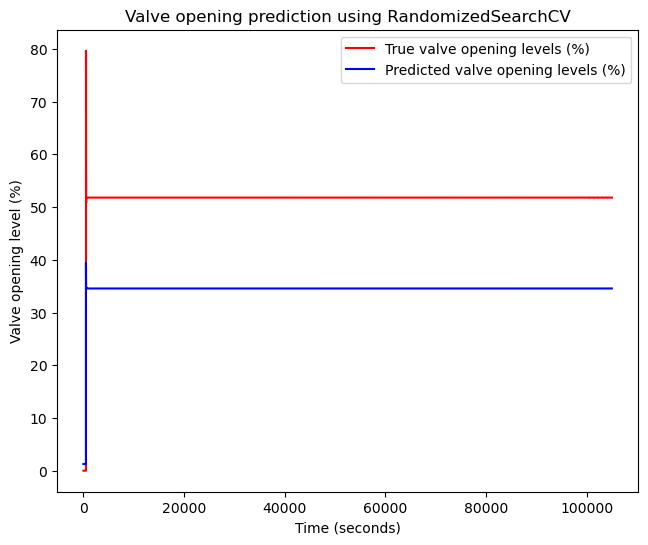

In [75]:
# Plotting the system output for rs_model_2
fig, ax15 = plt.subplots(figsize = (7.5,6))
ax15.plot(df_test_data_2.Time, y2_test, c = 'red', label = "True valve opening levels (%)")
ax15.plot(df_test_data_2.Time, rs_y2_preds, c = 'blue', label = "Predicted valve opening levels (%)")
ax15.set(xlabel = "Time (seconds)",
         ylabel = "Valve opening level (%)",
         title = "Valve opening prediction using RandomizedSearchCV")
ax15.legend();

In [76]:
time_vector_2 = np.linspace(0, 20376, df_test_data_2.Time.size)
time_returned5, sysout2 = ct.forced_response(0.0113*W_object, time_vector, rs_y2_preds) # Predicted liquid levels as per transfer function
time_returned6, sysout3 = ct.forced_response(0.0113*W_object, time_vector, y2_test)

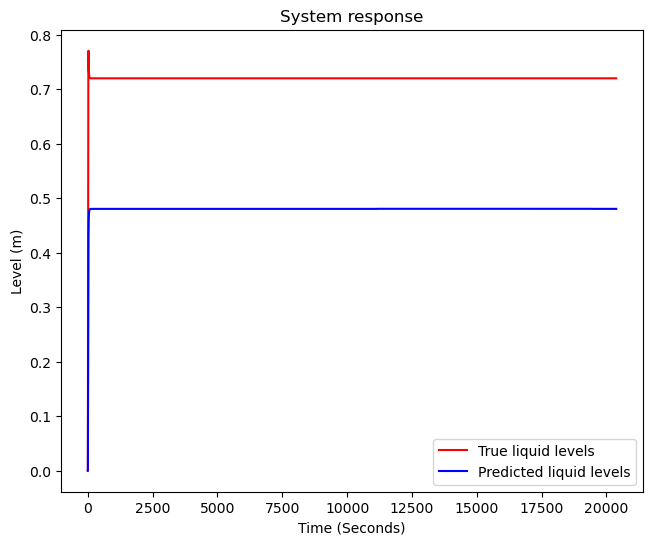

In [77]:
# Plotting the system output for rs_model_2
fig, ax17 = plt.subplots(figsize=(7.5, 6))
ax17.plot(time_returned6, sysout3, color = 'r', label = "True liquid levels")
ax17.plot(time_returned5, sysout2, color = 'b', label = "Predicted liquid levels")
ax17.set(title="System response",
        xlabel="Time (Seconds)",
        ylabel="Level (m)")
ax17.legend();

### 6.3. Improvisation using normalization

* It is well known that ML algorithms work better with numbers in the range of 0 and 1 rather than usual numbers.
* Therefore, the process of `normalization` is one of the methods of dealing with `overfitting` of a ML model
* Normalization can be done using a `column transformer` based on `MinMaxScaler` from `sklearn.preprocessing`

In [78]:
df_data3.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25474 entries, 0 to 25473
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Time             25474 non-null  float64
 1   Input            25474 non-null  float64
 2   Liquid_levels    25474 non-null  float64
 3   Feedback         25474 non-null  float64
 4   Valve_Positions  25474 non-null  float64
dtypes: float64(5)
memory usage: 995.2 KB


In [79]:
# Import make_column_transformer and MinMaxScaler
from sklearn.compose import make_column_transformer
from sklearn.preprocessing import MinMaxScaler
# Create a column transformer
ct1 = make_column_transformer((MinMaxScaler(), ["Input", "Liquid_levels", "Feedback"]), remainder = 'passthrough')
# Fit the column transformer with df_data3
ct1.fit(X2_train)

# Once the column transformer is fitted, now perform the column transformation
X2_train_normal = ct1.transform(X2_train) # Training data
X2_test_normal = ct1.transform(X2_test) # Test data
X2_val_normal = ct1.transform(X2_val)

In [80]:
# Fit the baseline model with the normalized data
model_2_norm = RandomForestRegressor(n_estimators = 100,
                                     criterion = 'absolute_error',
                                     n_jobs = -1,
                                     random_state = 48)
# Fit the recreated baseline model with normalized data
model_2_norm.fit(X2_train_normal, y2_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'absolute_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsampl

In [81]:
# Make predictions with the normalized data
y2_preds_norm = model_2_norm.predict(X2_test_normal)

In [82]:
y2_preds_norm[0]

0.73731863506436

In [83]:
# Check the mean_absolute_error
mean_absolute_error(y2_test, y2_preds_norm)

16.64887020522731

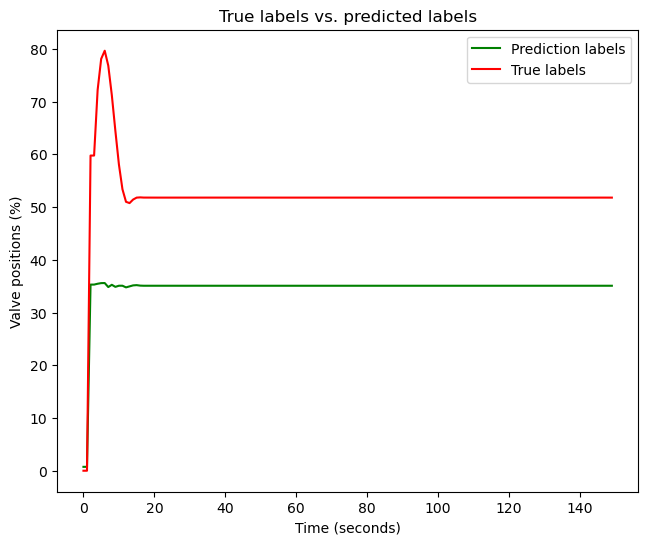

In [84]:
# Plot the valve positions obtained using normalization
fig, ax17 = plt.subplots(figsize = (7.5, 6))
ax17.plot(y2_preds_norm[:150], c = 'g', label = "Prediction labels")
ax17.plot(y2_test[:150], c = 'r', label = "True labels")
ax17.set(xlabel = "Time (seconds)",
         ylabel = "Valve positions (%)",
         title = "True labels vs. predicted labels")
ax17.legend();

## 7. Improvisation step-2

At this stage, the independent labels is to be changed to only the `feedback` labels. The dependent label remains as the `Valve_positions`. 
* Both labels are to be obtained from the `df_data3` database for training
* The test data is to be obtained from the `df_data2` database


### 7.1. Improvisation step-2: Preparing the training and test data


In [85]:
# Preparing input labels 
X3_train = df_data3.Feedback # Feedback is the only independent variable in this case
y3_train = df_data3.Valve_Positions # Valve positions is the target variable
X3_train = pd.DataFrame(X3_train) # Reshaping the X3_train to provide a 2D array instead of a 1-D array for fitting

In [86]:
X3_train.shape

(25474, 1)

In [87]:
model_3 = RandomForestRegressor(n_jobs = -1,
                                criterion = "absolute_error",
                                random_state=45)


In [88]:
%%time
# Time and fit the model
model_3.fit(X3_train, y3_train)

CPU times: total: 13.4 s
Wall time: 944 ms


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'absolute_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsampl

In [89]:
# Form the test datasets
X3_test = df_data2.Feedback
y3_test = df_data2.Valve_Positions


In [90]:
y3_preds = model_3.predict(pd.DataFrame(X3_test))

In [91]:
mean_absolute_error(y3_preds, y3_test)

9.298868220813606

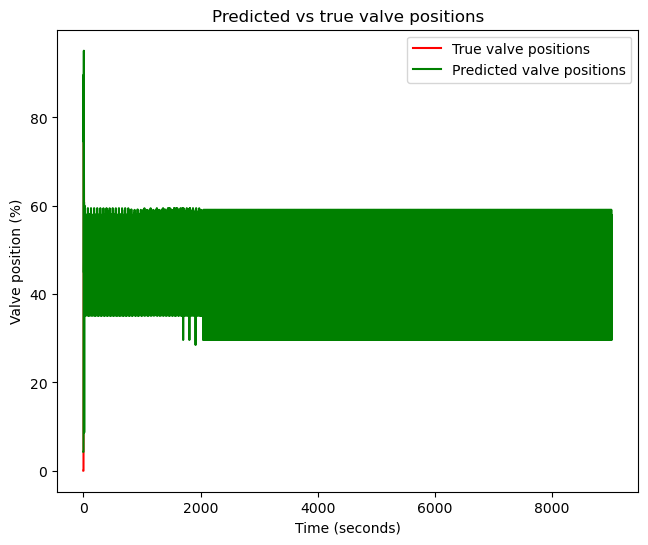

In [92]:
# Plot the predicted labels vs the true labels 
fig, ax13 = plt.subplots(figsize = (7.5, 6))
ax13.plot(y3_test, color = 'r', label = "True valve positions")
ax13.plot(y3_preds, color = 'g', label = "Predicted valve positions")
ax13.set(xlabel = "Time (seconds)",
         ylabel = "Valve position (%)",
         title = "Predicted vs true valve positions")
ax13.legend();

In [93]:
# Try to force this value upon the transfer function
time_vector_3 = np.linspace(0,10500, df_data2.Time.size)
time_returned_7, sysout4 = ct.forced_response(0.0113*W_object, time_vector_2, y3_test)
time_returned_8, sysout5 = ct.forced_response(0.0113*W_object, time_vector_2, y3_preds)

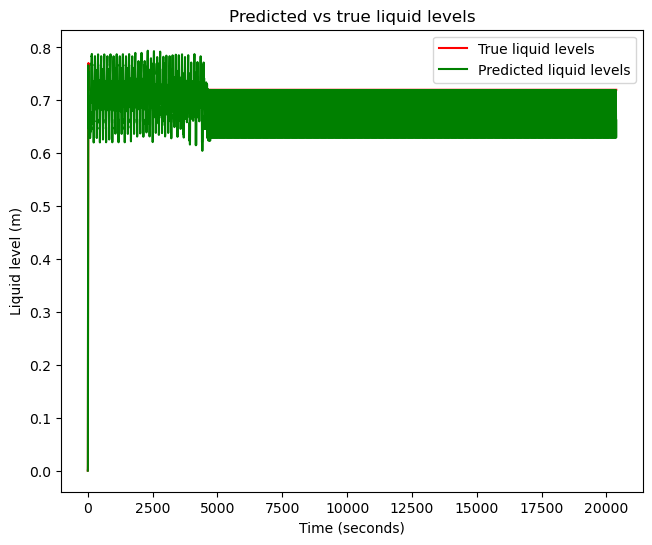

In [94]:
# Plot the system output
fig, ax14 = plt.subplots(figsize = (7.5, 6))
ax14.plot(time_returned_8, sysout4, color = 'r', label = "True liquid levels")
ax14.plot(time_returned_8, sysout5, color = 'g', label = "Predicted liquid levels")
ax14.set(xlabel = "Time (seconds)",
         ylabel = "Liquid level (m)",
         title = "Predicted vs true liquid levels")
ax14.legend();

### 7.2 Improvisation using RandomizedSearchCV

In [95]:
# Prepare the the rf_grid 
rf_grid_3 = {"n_estimators": np.arange(0,2000,10),
            "criterion": ["squared_error", "absolute_error", "poisson", "friedman_mse"],
            "max_depth": [None, 3, 5, 10, 15, 20],
            "min_samples_split": np.arange(2, 60, 2),
            "min_samples_leaf": np.arange(1,30,2),
            "max_features": [0.25, 0.5, 1.0, 'sqrt'],
            "max_samples":[None, 5000, 10000]}
# Create the RandomizedSearchCV
rs_model_3 = RandomizedSearchCV(RandomForestRegressor(n_jobs=-1,
                                                      random_state = 45),
                                param_distributions=rf_grid_3,
                                n_iter = 6, 
                                cv = 5,
                                verbose = True)

# Fit the model 
rs_model_3.fit(X3_train, y3_train)

Fitting 5 folds for each of 6 candidates, totalling 30 fits


C:\Users\anshu\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py:490: FitFailedWarning: 
5 fits failed out of a total of 30.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
5 fits failed with the following error:
Traceback (most recent call last):
  File "C:\Users\anshu\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py", line 833, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "C:\Users\anshu\anaconda3\Lib\site-packages\sklearn\base.py", line 1329, in wrapper
    estimator._validate_params()
  File "C:\Users\anshu\anaconda3\Lib\site-packages\sklearn\base.py", line 492, in _validate_params
    validate_parameter_constraints(
  File "C:\Users\anshu\anaconda3\Lib\site-packages\sk

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestR...ndom_state=45)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'criterion': ['squared_error', 'absolute_error', ...], 'max_depth': [None, 3, ...], 'max_features': [0.25, 0.5, ...], 'max_samples': [None, 5000, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",6
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies 

In [96]:
rs_model_3.best_params_

{'n_estimators': 240,
 'min_samples_split': 42,
 'min_samples_leaf': 21,
 'max_samples': 10000,
 'max_features': 0.25,
 'max_depth': 20,
 'criterion': 'friedman_mse'}

In [97]:
# Get the prediction labels for the test data
rs_y3_preds = rs_model_3.predict(pd.DataFrame(X3_test))

In [98]:
# Get the mean absolute error between the true and predicted labels 
mean_absolute_error(y3_test, rs_y3_preds)

9.9066677935536

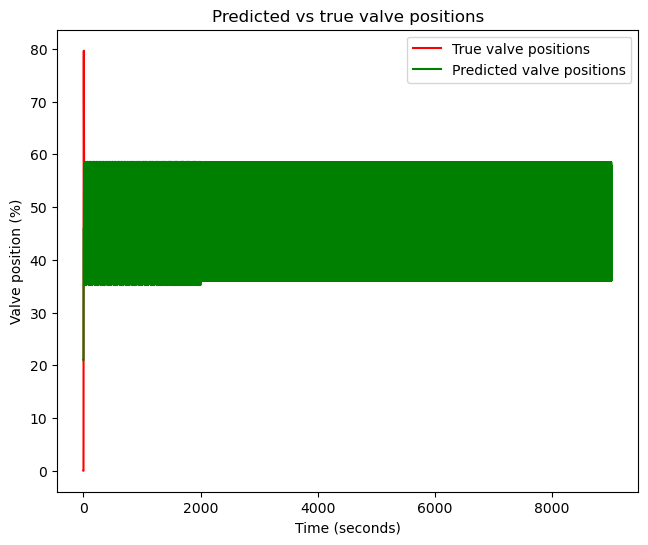

In [99]:
# Plot the predicted valve opening levels vs. the true valve opening levels
fig, ax15 = plt.subplots(figsize = (7.5, 6))
ax15.plot(y3_test, color = 'r', label = "True valve positions")
ax15.plot(rs_y3_preds, color = 'g', label = "Predicted valve positions")
ax15.set(xlabel = "Time (seconds)",
         ylabel = "Valve position (%)",
         title = "Predicted vs true valve positions")
ax15.legend();

In [100]:
# Prepare the predicted liquid levels based on the predicted valve opening levels 
time_returned_7, sysout6 = ct.forced_response(0.0113*W_object, time_vector_2, y3_test)
time_returned_8, sysout7 = ct.forced_response(0.0113*W_object, time_vector_2, rs_y3_preds)

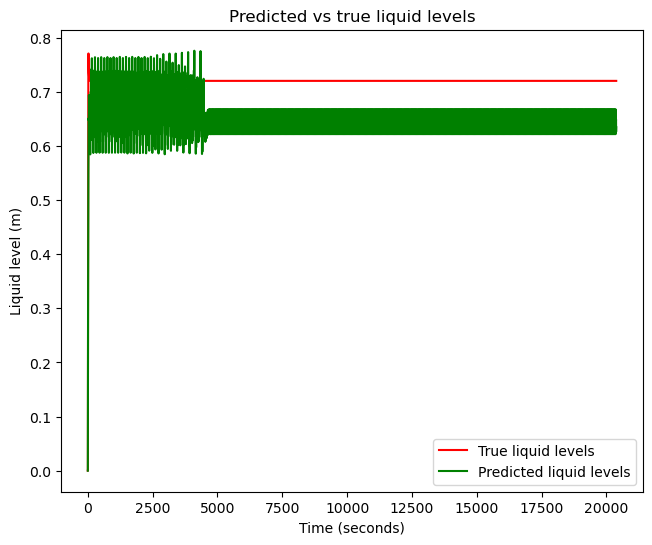

In [101]:
# Plot the system output
fig, ax16 = plt.subplots(figsize = (7.5, 6))
ax16.plot(time_returned_7, sysout6, color = 'r', label = "True liquid levels")
ax16.plot(time_returned_8, sysout7, color = 'g', label = "Predicted liquid levels")
ax16.set(xlabel = "Time (seconds)",
         ylabel = "Liquid level (m)",
         title = "Predicted vs true liquid levels")
ax16.legend();

### 7.3. Improvisation using GridSearchCV

In [102]:
# Create a grid 
#gs_grid = {"n_estimators": np.arange(500, 550, 10),
  #        "criterion":["absolute_error", "friedman_mse"],
  #        "max_features":[0.25, 0.5],
  #         "min_samples_leaf": [3, 25, 29],
  #        "min_samples_split":[8, 34, 52],
  #        "max_depth": [10, 20],
  #        }


In [103]:
# from sklearn.model_selection import GridSearchCV

In [104]:
#gs_model_3 = GridSearchCV(estimator = RandomForestRegressor(n_jobs = -1,
#                                                            random_state = 48),
#                          param_grid = gs_grid,
#                          cv = 5,
#                          verbose = True)

In [105]:
# %%time
# gs_model_3.fit(X3_train, y3_train)

In [106]:
# Get the mean absolute error and mean square error 
# gs_y3_preds = gs_model_3.predict(pd.DataFrame(X3_test))

# mean_absolute_error(y3_test, gs_y3_preds)

In [107]:
# Plot the predicted labels 
# fig, ax18 = plt.subplots(figsize = (7.5, 6))
# ax18.plot(y3_test[:300], color = 'r', label = "True valve positions")
# ax18.plot(gs_y3_preds[:300], color = 'b', label = "Predicted valve positions")
# ax18.set(xlabel = "Time (seconds)",
#         ylabel = "Valve position (%)",
#         title = "Predicted vs true valve positions")
# ax18.legend();

In [108]:
# Prepare the predicted liquid levels based on the predicted valve opening levels 
#time_returned_9, sysout8 = ct.forced_response(0.0113*W_object, time_vector_2, y3_test)
#time_returned_10, sysout9 = ct.forced_response(0.0113*W_object, time_vector_2, gs_y3_preds)

In [109]:
# Plot the system output
#fig, ax19 = plt.subplots(figsize = (7.5, 6))
#ax19.plot(time_returned_9[:300], sysout8[:300], color = 'r', label = "True liquid levels")
#ax19.plot(time_returned_10[:300], sysout9[:300], color = 'b', label = "Predicted liquid levels")
#ax19.set(xlabel = "Time (seconds)",
#         ylabel = "Liquid level (m)",
#         title = "Predicted vs true liquid levels")
#ax19.legend();

## 8. Modelling using catboost regressor

`Catboost` is another machine learning library, a bit different from `RandomForestRegressor`, which can also be used to fit and evaluate regression type data that is being used in the concerned control system database

The most important hyperparameters in catboost are:
* iterations
* learning_rate
* depth
* l2_leaf_reg
* model_size_reg
* loss_function
* random_seed
* use_best_model
* cat_features: To specify categorical features, which are absent in case of the databases used for liquid level control system
* feature_weights

### 8.1. Creating and fitting a catboost regressor model

In [110]:
# Create a catboost regressor model
catboost_model_1 = CatBoostRegressor(iterations = 100,
                                     learning_rate = 0.5,
                                     depth = 8,
                                     loss_function = 'MAE',
                                     random_seed = 48,
                                     use_best_model = None,
                                     verbose = False)
                                    
                         
                                 

Fit the model with the elongated data obtained from `training_data_from_matlab7.csv`, which has been splitted into training and test data as `X2_train` and `y2_train`

In [111]:
# Fit the model
catboost_model_1.fit(X2_train, y2_train, eval_set=(X2_val, y2_val))

### 8.2. Making predictions and evaluating the catboost regressor based model

Make some predictions using the `X2_test` and `y2_test` features and labels

In [112]:
cat_y2_preds = catboost_model_1.predict(X2_test)

In [113]:
mean_absolute_error(y2_test, cat_y2_preds)

9.547735836462204

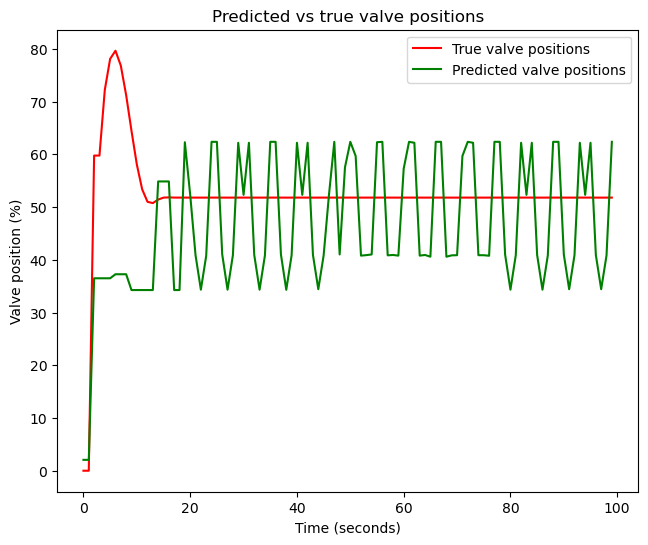

In [114]:
# Plot the predicted labels vs the true labels 
fig, ax20 = plt.subplots(figsize = (7.5, 6))
ax20.plot(y2_test[:100], color = 'r', label = "True valve positions")
ax20.plot(cat_y2_preds[:100], color = 'g', label = "Predicted valve positions")
ax20.set(xlabel = "Time (seconds)",
         ylabel = "Valve position (%)",
         title = "Predicted vs true valve positions")
ax20.legend();

In [115]:
time_returned11, sysout10 = ct.forced_response(0.0113*W_object, time_vector, cat_y2_preds) # Predicted liquid levels as per transfer function
time_returned12, sysout11 = ct.forced_response(0.0113*W_object, time_vector, y2_test)

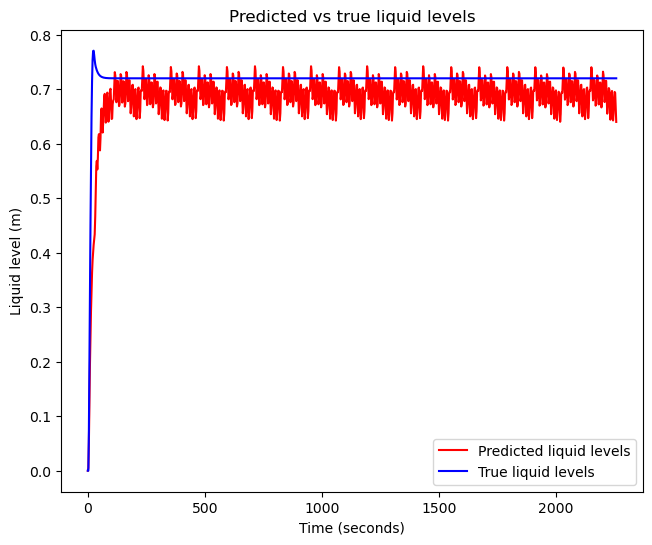

In [116]:
# Plot the system output
fig, ax22 = plt.subplots(figsize = (7.5, 6))
ax22.plot(time_returned11[:1000], sysout10[:1000], color = 'r', label = "Predicted liquid levels")
ax22.plot(time_returned12[:1000], sysout11[:1000], color = 'b', label = "True liquid levels")
ax22.set(xlabel = "Time (seconds)",
         ylabel = "Liquid level (m)",
         title = "Predicted vs true liquid levels")
ax22.legend();

#### 8.2.1: Tuning hyperparameters of the models to improvize the model
In this section, attention will be paid to parameters like `feature_weights`, `loss_function`, `learning_rate` etc

In [117]:
X2_test.head()

,Time,Input,Liquid_levels,Feedback
0,0.00,0.00,0.000000e+00,0.000000
1,500.00,0.00,0.000000e+00,0.000000
2,500.00,0.72,0.000000e+00,0.720000
3,500.00,0.72,2.510389e-13,0.720000
4,501.91,0.72,1.363256e-01,0.583674


In [118]:
# Create a catboost regressor model
catboost_model_2 = CatBoostRegressor(iterations = 250,
                                     learning_rate = 0.45,
                                     depth = 8,
                                     loss_function = 'MultiRMSE',
                                     random_seed = 48,
                                     feature_weights= [0.09, 0.35, 1.55, 1.45],
                                     use_best_model = None,
                                     eval_metric= 'MultiRMSE',
                                     verbose = False
                                    )

In [119]:
# Fit the model
catboost_model_2.fit(X2_train, y2_train, eval_set=(X2_val, y2_val))

In [120]:
# Score the model
catboost_model_2.score(X2_test, y2_test)

-221.4120306782051

In [121]:
# Check the mean absolute error
cat_y2_preds_2 = catboost_model_2.predict(X2_test)


In [122]:
mean_absolute_error(y2_test, cat_y2_preds_2)

14.244569618311205

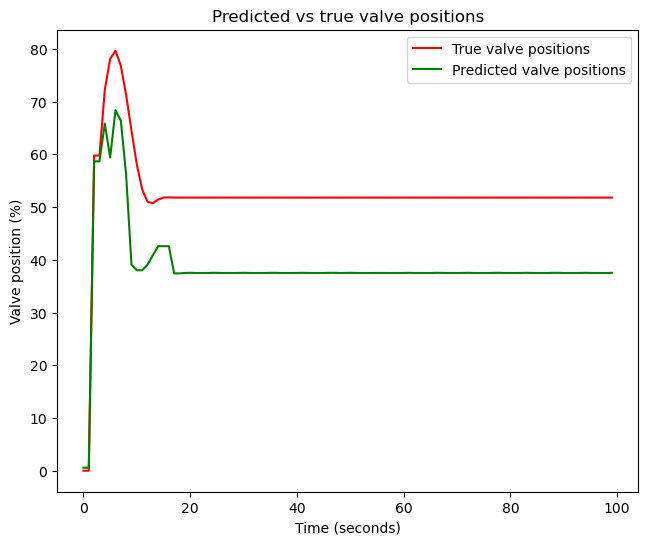

In [123]:
# Plot the predicted labels vs the true labels 
fig, ax23 = plt.subplots(figsize = (7.5, 6))
ax23.plot(y2_test[:100], color = 'r', label = "True valve positions")
ax23.plot(cat_y2_preds_2[:100], color = 'g', label = "Predicted valve positions")
ax23.set(xlabel = "Time (seconds)",
         ylabel = "Valve position (%)",
         title = "Predicted vs true valve positions")
ax23.legend();

In [124]:
# Export model
# Save an existing model to file
# pickle.dump(catboost_model_2, open("catboost_regressor_model_1.pkl", "wb"))

In [125]:
# pickle.dump(catboost_model_2, open("catboost_regressor_model_2.pkl", "wb"))

In [126]:
# pickle.dump(catboost_model_2, open("catboost_regressor_model_3.pkl", "wb"))

In [127]:
# pickle.dump(catboost_model_2, open("catboost_regressor_model_4.pkl", "wb"))

In [128]:
cat_y2_preds_2[0]

0.5721876755421249

In [129]:
# pickle.dump(catboost_model_2, open("catboost_regressor_model_7.pkl", "wb"))

In [130]:
# In this iteration we didn't get a good response from the catboost model, so we will be using the saved catboost models to make our predictions
loaded_pickle_catboost_model_2 = pickle.load(open("catboost_regressor_model_1.pkl","rb"))

In [131]:
# Make predictions using the 1st loaded catboost model
pickle_cat_y2_preds = loaded_pickle_catboost_model_2.predict(X2_test)

# Evaluate the predictions 
print(f" Mean absolute error: {mean_absolute_error(y2_test, pickle_cat_y2_preds)}")

 Mean absolute error: 3.8312776159408495


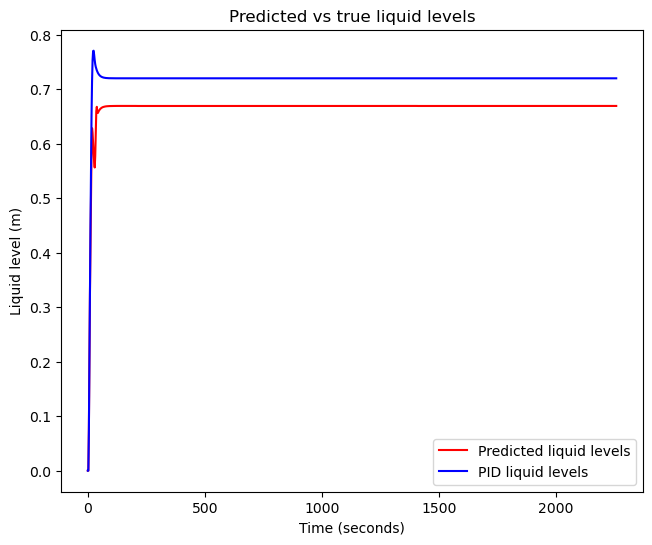

In [132]:
# Get the system outputs
time_returned13, sysout12 = ct.forced_response(0.0113*W_object, time_vector, pickle_cat_y2_preds) # Predicted liquid levels as per transfer function
time_returned14, sysout13 = ct.forced_response(0.0113*W_object, time_vector, y2_test)

# Plot the system output
fig, ax23 = plt.subplots(figsize = (7.5, 6))
ax23.plot(time_returned13[:1000], sysout12[:1000], color = 'r', label = "Predicted liquid levels")
ax23.plot(time_returned14[:1000], sysout13[:1000], color = 'b', label = "PID liquid levels")
ax23.set(xlabel = "Time (seconds)",
         ylabel = "Liquid level (m)",
         title = "Predicted vs true liquid levels")
ax23.legend();

In [133]:
# Get the second loaded model
loaded_pickle_catboost_model_3 = pickle.load(open("catboost_regressor_model_2.pkl", "rb"))

# Make predictions
pickle_cat_y2_preds_2 = loaded_pickle_catboost_model_3.predict(X2_test)

# Print the mean absolute error
print(f"Mean absolute error: {mean_absolute_error(y2_test, pickle_cat_y2_preds_2)}")

Mean absolute error: 3.8312776159408495


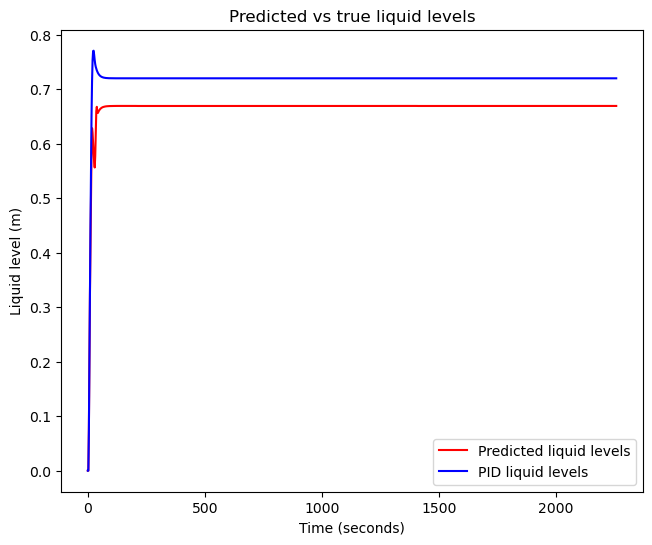

In [134]:
# Plot the system response
time_returned15, sysout14 = ct.forced_response(0.0113*W_object, time_vector, pickle_cat_y2_preds_2) # Predicted liquid levels as per transfer function
time_returned16, sysout15 = ct.forced_response(0.0113*W_object, time_vector, y2_test)

# Plot the system output
fig, ax24 = plt.subplots(figsize = (7.5, 6))
ax24.plot(time_returned15[:1000], sysout14[:1000], color = 'r', label = "Predicted liquid levels")
ax24.plot(time_returned16[:1000], sysout15[:1000], color = 'b', label = "PID liquid levels")
ax24.set(xlabel = "Time (seconds)",
         ylabel = "Liquid level (m)",
         title = "Predicted vs true liquid levels")
ax24.legend();

Mean absolute error: 3.558644195214485


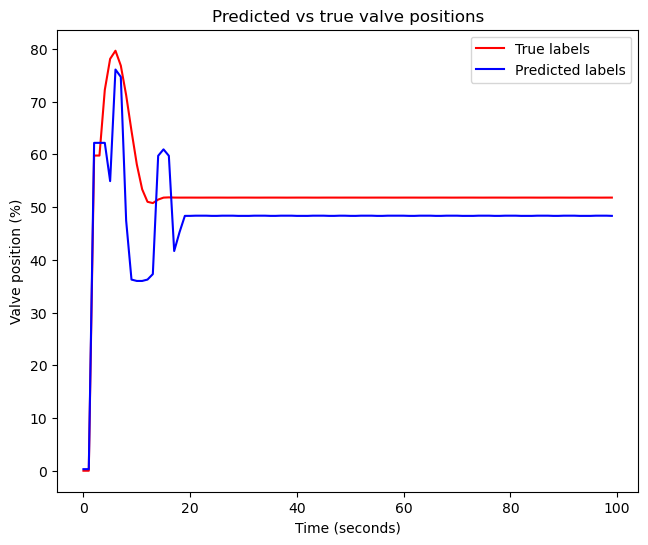

In [135]:
# Get the third loaded model
loaded_pickle_catboost_model_4 = pickle.load(open("catboost_regressor_model_3.pkl", "rb"))

# Make predictions
pickle_cat_y2_preds_3 = loaded_pickle_catboost_model_4.predict(X2_test)

# Print the mean absolute error
print(f"Mean absolute error: {mean_absolute_error(y2_test, pickle_cat_y2_preds_3)}")
fig, ax25 = plt.subplots(figsize = (7.5, 6))
ax25.plot(y2_test[:100], c = "red", label = "True labels")
ax25.plot(pickle_cat_y2_preds_3[:100], c = "blue", label = "Predicted labels")
ax25.set(xlabel = "Time (seconds)",
         ylabel = "Valve position (%)",
         title = "Predicted vs true valve positions")
ax25.legend();

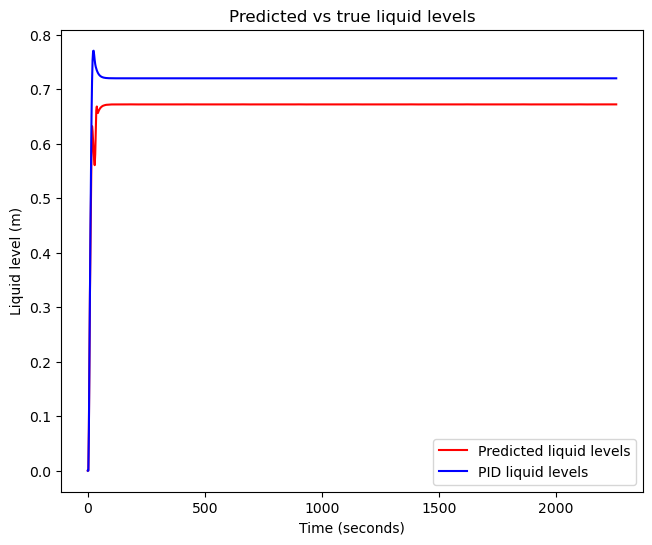

In [136]:
# Plot the system response
time_returned17, sysout16 = ct.forced_response(0.0113*W_object, time_vector, pickle_cat_y2_preds_3) # Predicted liquid levels as per transfer function
time_returned18, sysout17 = ct.forced_response(0.0113*W_object, time_vector, y2_test)

# Plot the system output
fig, ax26 = plt.subplots(figsize = (7.5, 6))
ax26.plot(time_returned17[:1000], sysout16[:1000], color = 'r', label = "Predicted liquid levels")
ax26.plot(time_returned18[:1000], sysout17[:1000], color = 'b', label = "PID liquid levels")
ax26.set(xlabel = "Time (seconds)",
         ylabel = "Liquid level (m)",
         title = "Predicted vs true liquid levels")
ax26.legend();

In [137]:
# Check the mean_absolute_error in the predicted liquid levels
print(f"The best possible catboost model is able to predict the liquid level with a mean absolute error of: {mean_absolute_error(sysout17,sysout16):.3f} meters, i.e. {(mean_absolute_error(sysout17,sysout16)/0.72)*100:.3f} %")

The best possible catboost model is able to predict the liquid level with a mean absolute error of: 0.049 meters, i.e. 6.853 %


### 8.2.2. Catboost hyperparameter tuning using RandomizedSearchCV

#### 8.2.2.1. Using `catboost`'s in-build `random_seach`

Like `RandomForestRegressor`, `catboost` also supports both `RandomizedSearchCV` and `GridSearchCV`
* In case of catboost, the RandomizedSearchCV is called `random_search`
* GridSearchCV is called `grid_search` and they both can be called upon as an attribute to the model

In order to utilize `random_search`, it is required to define a param_distribution first

In [138]:
# Define the param_grid which we will use to search for the best parameters
catboost_model_3 = CatBoostRegressor(loss_function="Quantile",
                                    eval_metric= "MAE",
                                    random_seed = 48,
                                    verbose = False)
rs_param_grid = {
    "iterations": np.arange(50, 300, 50),
    "learning_rate": [0.45, 0.5, 0.55, 0.6],
    "depth": [6, 7, 8, 9, 10],
    "l2_leaf_reg": [1, 3, 5, 7, 9],
    "feature_weights": [[0.09, 0.35, 1.55, 1.45], [0.09, 0.35, 1.3, 1.3], [0.09, 0.4, 1.65, 1.5]]
    }

randomized_search_result = catboost_model_3.randomized_search(param_distributions=rs_param_grid,
                                                              X = X2,
                                                              y = y2,
                                                              plot = False)
                                                              
            



bestTest = 0.05470563107
bestIteration = 198

0:	loss: 0.0547056	best: 0.0547056 (0)	total: 709ms	remaining: 6.38s

bestTest = 0.05312158545
bestIteration = 197

1:	loss: 0.0531216	best: 0.0531216 (1)	total: 1.38s	remaining: 5.54s

bestTest = 0.04170576478
bestIteration = 99

2:	loss: 0.0417058	best: 0.0417058 (2)	total: 1.83s	remaining: 4.28s

bestTest = 0.02344779308
bestIteration = 148

3:	loss: 0.0234478	best: 0.0234478 (3)	total: 3.74s	remaining: 5.61s

bestTest = 0.04202616945
bestIteration = 249

4:	loss: 0.0420262	best: 0.0234478 (3)	total: 6.61s	remaining: 6.61s

bestTest = 0.05517613058
bestIteration = 99

5:	loss: 0.0551761	best: 0.0234478 (3)	total: 6.93s	remaining: 4.62s

bestTest = 0.07986614609
bestIteration = 227

6:	loss: 0.0798661	best: 0.0234478 (3)	total: 7.96s	remaining: 3.41s

bestTest = 0.06626864656
bestIteration = 49

7:	loss: 0.0662686	best: 0.0234478 (3)	total: 8.23s	remaining: 2.06s

bestTest = 0.08495303327
bestIteration = 99

8:	loss: 0.0849530	best: 0.02

In [139]:
randomized_search_result["params"]

{'feature_weights': [0.09, 0.35, 1.3, 1.3],
 'depth': 10,
 'learning_rate': 0.5,
 'l2_leaf_reg': 7,
 'iterations': 150}

In [140]:
# Make predictions using the optimized model
cat_y2_preds_3 = catboost_model_3.predict(X2_test)

In [141]:
# Get the mean_absolute_error
mean_absolute_error(y2_test, cat_y2_preds_3), catboost_model_3.score(X2_test, y2_test)


(7.4557951331252585, -65.64747237105337)

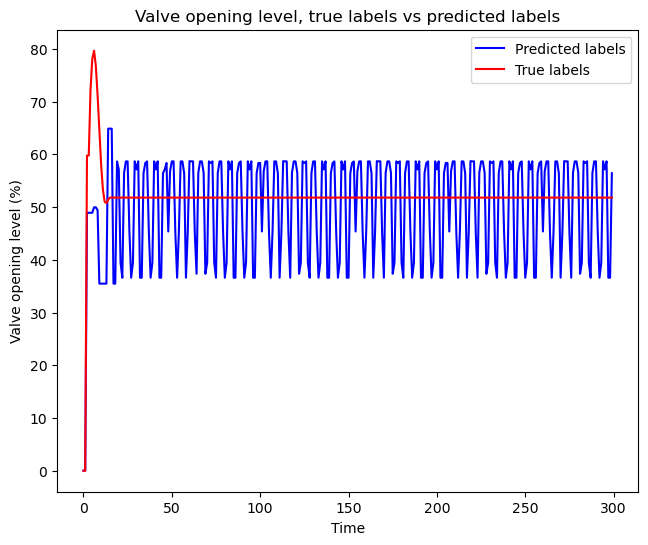

In [142]:
# Try plotting the results obtained from the rs_optimized model
fig, ax27 = plt.subplots(figsize = (7.5, 6))
ax27.plot(cat_y2_preds_3[:300], c = "b", label = "Predicted labels")
ax27.plot(y2_test[:300], c = "r", label = "True labels")
ax27.set(xlabel = "Time",
         ylabel = "Valve opening level (%)",
         title = "Valve opening level, true labels vs predicted labels")
ax27.legend();
            

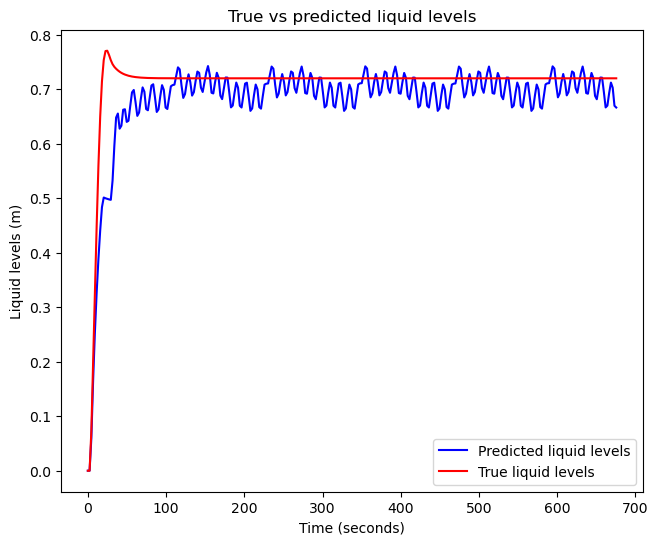

In [143]:
# Plot the predicted liquid levels by using ct.forced_response
time_returned_19, sysout18 = ct.forced_response(0.0113*W_object, time_vector, cat_y2_preds_3)
time_returned_20, sysout19 = ct.forced_response(0.0113*W_object, time_vector, y2_test)

fig, ax28 = plt.subplots(figsize = (7.5, 6))
ax28.plot(time_returned_19[:300], sysout18[:300], c = 'b', label = "Predicted liquid levels")
ax28.plot(time_returned_20[:300], sysout19[:300], c = 'r', label = "True liquid levels")
ax28.set(xlabel = "Time (seconds)",
         ylabel = "Liquid levels (m)",
         title = "True vs predicted liquid levels")
ax28.legend();

### 8.3. Using catboost on dataset with just the feedback as independent variable

At this stage instead of using all the parameters like `Time`, `Input`, `Liquid_levels` and `Feedback`, only `Feedback` will be used as the independent variable i.e. feature and `Valve_Positions` is to be used as the label i.e. dependent variable.

These dataframes for both training the model and evaluating the model are available in the form of `X3_train`, `y3_train` (training feature and label) and `X3_test`, `y3_test` (testing feature and label)

In [144]:
# Create the baseline catboost regressor model
catboost_model_4 = CatBoostRegressor(iterations = 100,
                                    learning_rate = 0.3,
                                    depth = 8,
                                    loss_function = 'MultiRMSE',
                                    eval_metric = 'MultiRMSE',
                                    random_seed = 48,
                                    use_best_model = None,
                                    verbose = False,
                                    )

# Fit the model with X3_train and y3_train
catboost_model_4.fit(X3_train, y3_train,
                     eval_set = (X3_test, y3_test),
                     plot = True)

MetricVisualizer(layout=Layout(align_self='stretch', height='500px'))

In [145]:
# Make predictyons and evaluate the model using X3_test, y3_test
cat_y3_preds_1 = catboost_model_4.predict(pd.DataFrame(X3_test))
# Using mean_absolute_error
print(f"The mean absolute error for catboost_model_4 is {mean_absolute_error(y3_test, cat_y3_preds_1)} %")

The mean absolute error for catboost_model_4 is 3.8773418892732985 %


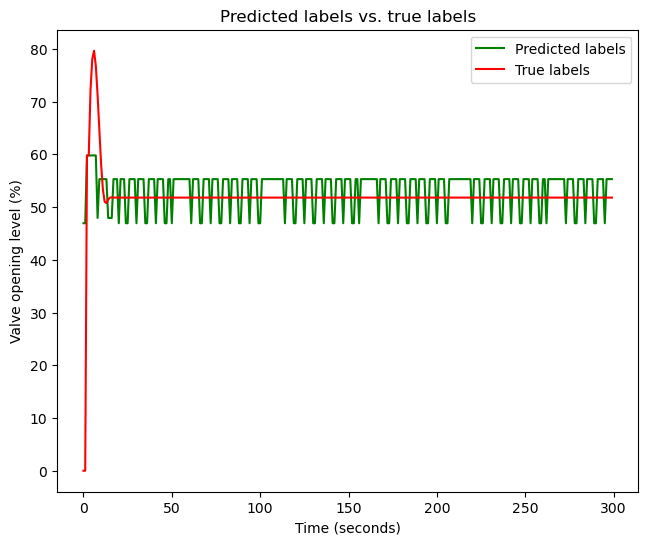

In [146]:
# Plot the predictions
fig, ax29 = plt.subplots(figsize = (7.5,6))
ax29.plot(cat_y3_preds_1[:300], c = 'g', label = "Predicted labels")
ax29.plot(y3_test[:300], c ='r', label = "True labels")
ax29.set(xlabel = "Time (seconds)",
         ylabel = "Valve opening level (%)",
         title = "Predicted labels vs. true labels")
ax29.legend();

#### 8.3.1. Use `random_search` attribute of catboost to improvise the model

In [147]:
# Create a rs_param_grid
rs_param_grid_2 = {
    "iterations": np.arange(50, 300, 50),
    "learning_rate": [0.45, 0.5, 0.55, 0.6],
    "depth": [6, 7, 8, 9, 10],
    "l2_leaf_reg": [1, 3, 5, 7, 9]    
    }
# Get a catboost model again
catboost_model_5 = CatBoostRegressor(loss_function = "MultiRMSE",
                                    eval_metric = "MultiRMSE",
                                    random_seed = 48,
                                    use_best_model = None,
                                    verbose = False)

# Ready the random_search
randomized_search_result_2 = catboost_model_5.randomized_search(param_distributions=rs_param_grid_2,
                                                              X = X3_train,
                                                              y = y3_train,
                                                              plot = False)


bestTest = 2.326021053
bestIteration = 94

0:	loss: 2.3260211	best: 2.3260211 (0)	total: 219ms	remaining: 1.97s

bestTest = 2.22697912
bestIteration = 199

1:	loss: 2.2269791	best: 2.2269791 (1)	total: 834ms	remaining: 3.34s

bestTest = 2.276457097
bestIteration = 199

2:	loss: 2.2764571	best: 2.2269791 (1)	total: 1.34s	remaining: 3.13s

bestTest = 2.374750921
bestIteration = 84

3:	loss: 2.3747509	best: 2.2269791 (1)	total: 1.64s	remaining: 2.46s

bestTest = 2.273841734
bestIteration = 229

4:	loss: 2.2738417	best: 2.2269791 (1)	total: 2.43s	remaining: 2.43s

bestTest = 2.498688593
bestIteration = 49

5:	loss: 2.4986886	best: 2.2269791 (1)	total: 2.62s	remaining: 1.75s

bestTest = 2.276305805
bestIteration = 94

6:	loss: 2.2763058	best: 2.2269791 (1)	total: 3.1s	remaining: 1.33s

bestTest = 2.409542324
bestIteration = 44

7:	loss: 2.4095423	best: 2.2269791 (1)	total: 3.63s	remaining: 907ms

bestTest = 2.279607909
bestIteration = 147

8:	loss: 2.2796079	best: 2.2269791 (1)	total: 5.18

In [148]:
# Predict and evaluate
cat_y3_preds_2 = catboost_model_5.predict(pd.DataFrame(X3_test))
# Check the mean_absolute_error
print(f"The mean absolute error for catboost_model_5 is {mean_absolute_error(y3_test, cat_y3_preds_2)} %")

The mean absolute error for catboost_model_5 is 9.598876376117614 %


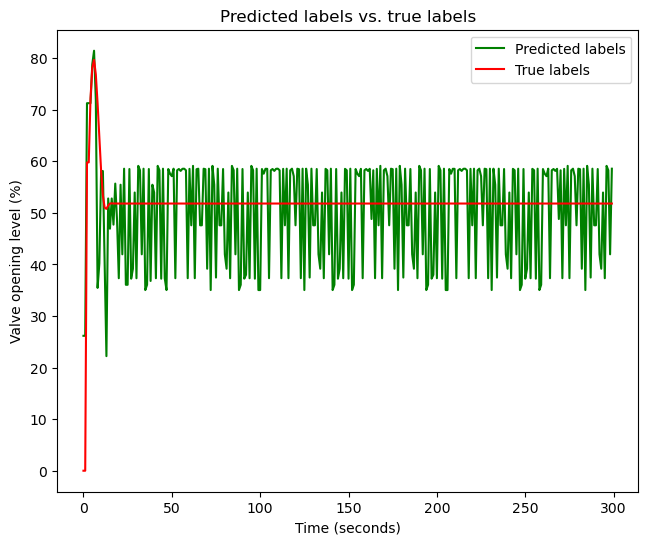

In [149]:
# Plot the predictions
fig, ax30 = plt.subplots(figsize = (7.5,6))
ax30.plot(cat_y3_preds_2[:300], c = 'g', label = "Predicted labels")
ax30.plot(y3_test[:300], c ='r', label = "True labels")
ax30.set(xlabel = "Time (seconds)",
         ylabel = "Valve opening level (%)",
         title = "Predicted labels vs. true labels")
ax30.legend();

## 9. Create another dataframe with more information

### 9.1. Use the `preprocess_data` function to obtain an even larger dataframe

An even larger dataframe will be obtained to train the `CatBoostRegressor` model using the `training_data_from_matlab12.csv` dataset

In [150]:
FILE_PATH = "training_data_from_matlab15.csv"
df_data4 = preprocess_data(FILE_PATH)

Reading data....
Changing the Time data from string to numeric....
Checking for string type data....
There are no strings in:  Time
There are no strings in:  Input
There are no strings in:  Liquid_levels
There are no strings in:  Feedback
There are no strings in:  Valve_Positions
Checking for missing data....
There are no missing values in:  Time
There are no missing values in:  Input
There are no missing values in:  Liquid_levels
There are no missing values in:  Feedback
There are no missing values in:  Valve_Positions
Checking for erroneous data....
Preprocessing complete....
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 5 columns):
 #   Column           Non-Null Count    Dtype  
---  ------           --------------    -----  
 0   Time             1048575 non-null  float64
 1   Input            1048575 non-null  float64
 2   Liquid_levels    1048575 non-null  float64
 3   Feedback         1048575 non-null  float64
 4   Valve_Posi

Test data for the same is to be taken from `training_data_from_matlab16.csv`

In [151]:
FILE_PATH = "training_data_from_matlab16.csv"
df_test_data_3 = preprocess_data(FILE_PATH)

Reading data....
Changing the Time data from string to numeric....
Checking for string type data....
There are no strings in:  Time
There are no strings in:  Input
There are no strings in:  Liquid_levels
There are no strings in:  Feedback
There are no strings in:  Valve_Positions
Checking for missing data....
There are no missing values in:  Time
There are no missing values in:  Input
There are no missing values in:  Liquid_levels
There are no missing values in:  Feedback
There are no missing values in:  Valve_Positions
Checking for erroneous data....
Preprocessing complete....
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13236 entries, 0 to 13235
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Time             13236 non-null  float64
 1   Input            13236 non-null  float64
 2   Liquid_levels    13236 non-null  float64
 3   Feedback         13236 non-null  float64
 4   Valve_Positions  13236 non

In this section, the actuator also plays a role and has a transfer function of its own

In [152]:
W_AC = ct.tf([0.0113],[37.92, 1]) 

In [153]:
W_AC

TransferFunction(array([0.0113]), array([37.92,  1.  ]))

### 9.1.1. Prepare the dataframe for modelling

In [154]:
X4_train, y4_train = prepare_for_modelling(df_data4)

In [155]:
# Prepare the test data
X4_test, y4_test = prepare_for_modelling(df_test_data_3)

The training dataframe is set. The test dataframe will be `X4_test` (features) & `y4_test` (labels)

In [156]:
catboost_model_6 = CatBoostRegressor(iterations = 200,
                                     learning_rate = 0.5,
                                     depth = 8,
                                     l2_leaf_reg = 3,
                                     loss_function = "MAE",
                                     random_seed = 48,
                                     feature_weights = [0.1, 1.5, 1.9, 1.5], 
                                     use_best_model = None,
                                     eval_metric= "RMSE",
                                     verbose = False)

# Fit the model
catboost_model_6.fit(X4_train, y4_train,
                     eval_set = (X2_test, y2_test))

In [157]:
#[0.1, 0.5, 1.7, 1.45]
#[0.1, 0.5, 1.7, 1.6]
#[0.1, 1, 1.35, 1.45]
#[0.1, 1.4, 1.65, 1.5]
#[0.1, 1.3, 1.65, 1.5]
#[0.1, 1.5, 1.9, 1.5]

In [158]:
# Make predictions and get the mean_absolute_error
cat_y4_preds_1 = catboost_model_6.predict(X2_test)
# Get the mean_absolute_error
print(f"The mean absolute error for catboost_model_6 is {mean_absolute_error(y2_test, cat_y4_preds_1)} (%)")

The mean absolute error for catboost_model_6 is 8.748460194192312 (%)


In [159]:
mean_absolute_error(y2_test, cat_y4_preds_1)

8.748460194192312

In [160]:
cat_y4_preds_1[0]

-4.3840546481987985e-07

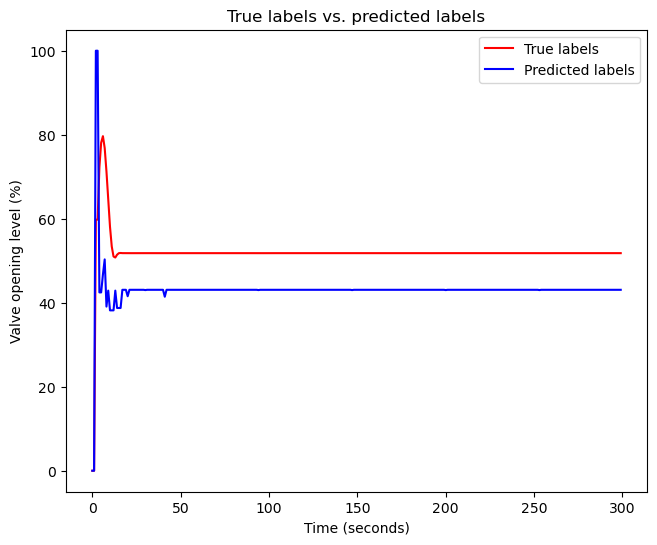

In [161]:
# Plot the output of the model with even larger training dataset
fig, ax31 = plt.subplots(figsize = (7.5,6))
ax31.plot(y2_test[:300], c = 'r', label = "True labels")
ax31.plot(cat_y4_preds_1[:300], c = 'b', label = "Predicted labels")
ax31.set(xlabel = "Time (seconds)",
         ylabel = "Valve opening level (%)",
         title = "True labels vs. predicted labels")
ax31.legend();

In [162]:
#pickle.dump(catboost_model_6, open("catboost_regressor_model_9.pkl", "wb"))

In [163]:
len(df_test_data_3)

13236

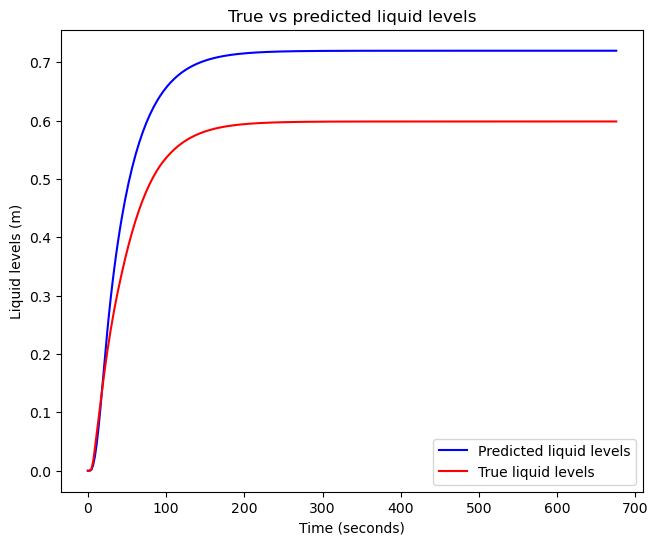

In [164]:
#time_vector2 = np.linspace(0, 13236, df_test_data_3.Time.size)
time_returned_21, sysout20 = ct.forced_response(W_AC*W_object, time_vector, cat_y4_preds_1)
time_returned_22, sysout21 = ct.forced_response(W_AC*W_object, time_vector, y2_test)
# Plot the liquid levels as per the predicted valve positions
fig, ax32 = plt.subplots(figsize = (7.5,6))
ax32.plot(time_returned_22[:300], sysout21[:300], c = 'b', label = "Predicted liquid levels")
ax32.plot(time_returned_21[:300], sysout20[:300], c = 'r', label = "True liquid levels")
ax32.set(xlabel = "Time (seconds)",
         ylabel = "Liquid levels (m)",
         title = "True vs predicted liquid levels")
ax32.legend();

In [165]:
mean_absolute_error(sysout20, sysout21), ((mean_absolute_error(sysout20, sysout21))/0.75)*100

(0.12106395519708017, 16.141860692944025)

In [166]:
# Use the loaded best model so far....
loaded_catboost_model_6 =  pickle.load(open("catboost_regressor_model_6.pkl", "rb"))

In [167]:
# Make some predictions
pickle_cat_y4_preds_1 = loaded_catboost_model_6.predict(X2_test)
# Check mean_absolute_error
print(f"The mean absolute error for loaded_catboost_model_6 is {mean_absolute_error(y2_test, pickle_cat_y4_preds_1)} (%)")

The mean absolute error for loaded_catboost_model_6 is 9.273819289874547 (%)


## 10. Now make predictions on `catboost` using modified dataframes

### 10.1. Create the modified dataframes
#### 10.1.1. Create modified dataframes out of the large dataframe i.e. `df_data3`
At this stage, the features are to be modified

1. Dataframe with `Input`, `Liquid_level` and `Feedback` features
2. Dataframe with `Input` and `Feedback` features
3. Dataframe with `Input` and `Liquid_levels` features 


In [168]:
# Create the dataframe with Input, Liquid_level and Feedback features as well as the labels (Valve_positions)
# df_data3
# df_test_data_2
df_training_1 = df_data3.drop("Time", axis = 1)
df_test_1 = df_test_data_2.drop("Time", axis = 1)

In [169]:
df_training_1.info(), df_test_1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25474 entries, 0 to 25473
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Input            25474 non-null  float64
 1   Liquid_levels    25474 non-null  float64
 2   Feedback         25474 non-null  float64
 3   Valve_Positions  25474 non-null  float64
dtypes: float64(4)
memory usage: 796.2 KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9021 entries, 0 to 9020
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Input            9021 non-null   float64
 1   Liquid_levels    9021 non-null   float64
 2   Feedback         9021 non-null   float64
 3   Valve_Positions  9021 non-null   float64
dtypes: float64(4)
memory usage: 282.0 KB


(None, None)

In [170]:
X5_train, y5_train = prepare_for_modelling(df_training_1)

In [171]:
X5_test, y5_test = prepare_for_modelling(df_test_1)

* The training features, labels as well as the testing features and labels are prepared.
* The next step is to create the `CatBoostRegressor` baseline model and make the first predictions

In [172]:
# Create the CatBoostRegressor model
catboost_model_7 = CatBoostRegressor(iterations = 100,
                                     learning_rate = 0.65,
                                     depth = 8,
                                     loss_function = "MultiRMSE",
                                     random_seed = 48,
                                     feature_weights= [90, 250, 250], 
                                     use_best_model = None,
                                     eval_metric= 'MultiRMSE',
                                     verbose = False)

# Fit the model
catboost_model_7.fit(X5_train, y5_train,
                     eval_set = (X5_test, y5_test))

In [173]:
# Weight set_1 = [0.09, 0.35, 1.55, 1.45]
# Weight set 2 = [0.09, 0.4, 1.65, 1.5]
# Weight set 3 = [0.09, 0.35, 1.3, 1.3]

In [174]:
# Evaluate the model
cat_y5_preds_1 = catboost_model_7.predict(X5_test)
# Get the mean_absolute_error
print(f"The mean absolute error for catboost_model_7 is {mean_absolute_error(y5_test, cat_y5_preds_1)} %")

The mean absolute error for catboost_model_7 is 0.2330391594130305 %


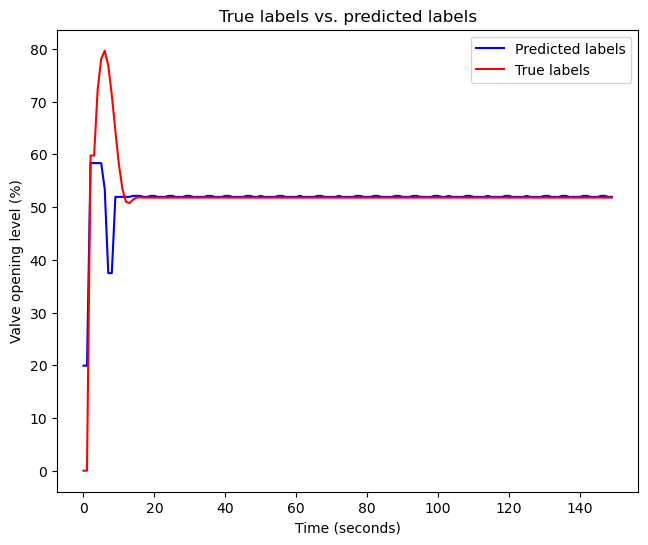

In [175]:
fig, ax33 = plt.subplots(figsize = (7.5,6))
ax33.plot(cat_y5_preds_1[:150], c = 'b', label = "Predicted labels")
ax33.plot(y5_test[:150], c = 'r', label = "True labels")
ax33.set(xlabel = "Time (seconds)",
         ylabel = "Valve opening level (%)",
         title = "True labels vs. predicted labels")
ax33.legend();

#### 10.1.2. Create modified dataframes out of the larger dataframe `df_data4`

The steps to be followed in this section are the same steps as section 10.1.1, but only with another dataframem, i.e.,
At this stage, the features are to be modified

1. Dataframe with `Input`, `Liquid_level` and `Feedback` features
2. Dataframe with `Input` and `Feedback` features
3. Dataframe with `Input` and `Liquid_levels` features 

In [176]:
# Create modified dataframes with df_data4 and df_test_data_2
df_training_2 = df_data4.drop("Time", axis = 1)
df_test_2 = df_test_data_2.drop("Time", axis = 1)

In [177]:
df_training_2.info(), df_test_2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 4 columns):
 #   Column           Non-Null Count    Dtype  
---  ------           --------------    -----  
 0   Input            1048575 non-null  float64
 1   Liquid_levels    1048575 non-null  float64
 2   Feedback         1048575 non-null  float64
 3   Valve_Positions  1048575 non-null  float64
dtypes: float64(4)
memory usage: 32.0 MB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9021 entries, 0 to 9020
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Input            9021 non-null   float64
 1   Liquid_levels    9021 non-null   float64
 2   Feedback         9021 non-null   float64
 3   Valve_Positions  9021 non-null   float64
dtypes: float64(4)
memory usage: 282.0 KB


(None, None)

In [178]:
# Prepare the training and the test data for modelling
X6_train, y6_train = prepare_for_modelling(df_training_2)
X6_test, y6_test = prepare_for_modelling(df_test_2)

In [179]:
# We have the training and test data, now its time for modelling
# Create the baseline model
catboost_model_8 = CatBoostRegressor(iterations = 100, 
                                     learning_rate = 0.75,
                                     loss_function = "MAE",
                                     random_seed = 48,
                                     feature_weights = [480, 180, 260], #[120, 45, 65]
                                     use_best_model = None, 
                                     eval_metric = "RMSE",
                                     verbose = False)

# Fit the training data
catboost_model_8.fit(X6_train, y6_train,
                     eval_set = (X6_test, y6_test))

In [180]:
# make some predictions 
cat_y6_preds_1 = catboost_model_8.predict(X6_test)
# Calculate the mean_absolute_error
print(f"The mean absolute error for catboost_model_8 is {mean_absolute_error(y6_test, cat_y6_preds_1)} (% valve opening)")

The mean absolute error for catboost_model_8 is 10.859301988262345 (% valve opening)


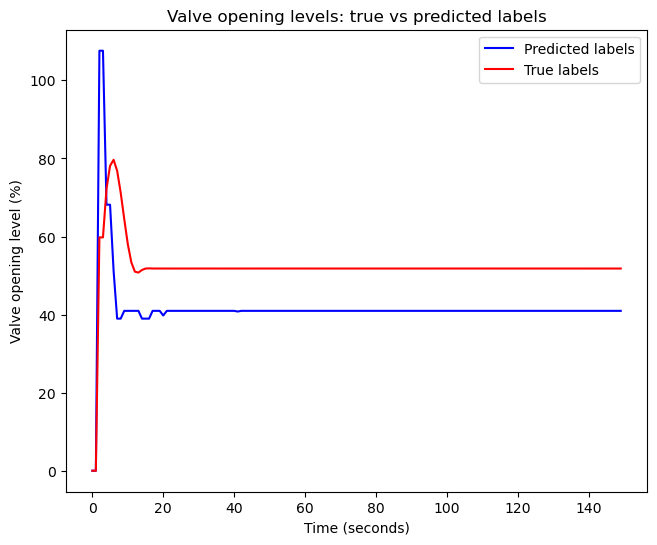

In [181]:
# Plot the valve opening levels
fig, ax34 = plt.subplots(figsize = (7.5, 6))
ax34.plot(cat_y6_preds_1[:150], c = 'b', label = "Predicted labels")
ax34.plot(y6_test[:150], c = 'r', label = "True labels")
ax34.set(xlabel = "Time (seconds)",
         ylabel = "Valve opening level (%)",
         title = "Valve opening levels: true vs predicted labels")
ax34.legend();

##### 10.1.2.1. Improvisation of `catboost_model_8` using `random_search`

In [182]:
# Create a catboost regressor 
catboost_model_9 = CatBoostRegressor(random_seed = 48,
                                     loss_function = "MAE",
                                     eval_metric = "RMSE",
                                     verbose = False)
# Create a param_greed
rs_param_grid_3 = {
    "iterations": np.arange(50, 300, 50),
    "learning_rate": [0.45, 0.5, 0.55, 0.6, 0.65, 0.7, 0.75],
    "depth": [6, 7, 8, 9, 10],
    "l2_leaf_reg": [1, 3, 5, 7, 9],
    "feature_weights": [[10, 6, 8], [120, 45, 65], [480, 180, 260]]
    }

# Setup the rs_model
randomized_search_result_3 = catboost_model_9.randomized_search(param_distributions = rs_param_grid_3,
                                                                X = X6_train,
                                                                y = y6_train,
                                                                cv = 5,
                                                                plot = False,
                                                                )


bestTest = 0.2687406098
bestIteration = 148

0:	loss: 0.2687406	best: 0.2687406 (0)	total: 9.94s	remaining: 1m 29s

bestTest = 0.2397174014
bestIteration = 199

1:	loss: 0.2397174	best: 0.2397174 (1)	total: 26.7s	remaining: 1m 46s

bestTest = 0.2752310719
bestIteration = 49

2:	loss: 0.2752311	best: 0.2397174 (1)	total: 29.8s	remaining: 1m 9s

bestTest = 0.2803704709
bestIteration = 126

3:	loss: 0.2803705	best: 0.2397174 (1)	total: 44.4s	remaining: 1m 6s

bestTest = 0.2381920309
bestIteration = 87

4:	loss: 0.2381920	best: 0.2381920 (4)	total: 52.6s	remaining: 52.6s

bestTest = 0.2410403418
bestIteration = 186

5:	loss: 0.2410403	best: 0.2381920 (4)	total: 1m 9s	remaining: 46.1s

bestTest = 0.2805550257
bestIteration = 99

6:	loss: 0.2805550	best: 0.2381920 (4)	total: 1m 16s	remaining: 32.8s

bestTest = 0.2392744327
bestIteration = 99

7:	loss: 0.2392744	best: 0.2381920 (4)	total: 1m 24s	remaining: 21s

bestTest = 0.252896897
bestIteration = 79

8:	loss: 0.2528969	best: 0.2381920 (4)

In [183]:
# Now that we have the rs model fitted we can make predictions
cat_y6_preds_2 = catboost_model_9.predict(X6_test)

# Get the mean_absolute_error
print(f"The mean absolute error for catboost_model_9 is {mean_absolute_error(y6_test, cat_y6_preds_2)} (% valve opening)")

The mean absolute error for catboost_model_9 is 13.306810946644209 (% valve opening)


#### 10.1.3 Create modified dataframes out of `df_data3` and `df_test_data_2` with only `Input` and `Feedback` as features

In [184]:
# Check the training and test datasets
df_data3.info(), df_test_data_2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25474 entries, 0 to 25473
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Time             25474 non-null  float64
 1   Input            25474 non-null  float64
 2   Liquid_levels    25474 non-null  float64
 3   Feedback         25474 non-null  float64
 4   Valve_Positions  25474 non-null  float64
dtypes: float64(5)
memory usage: 995.2 KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9021 entries, 0 to 9020
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Time             9021 non-null   float64
 1   Input            9021 non-null   float64
 2   Liquid_levels    9021 non-null   float64
 3   Feedback         9021 non-null   float64
 4   Valve_Positions  9021 non-null   float64
dtypes: float64(5)
memory usage: 352.5 KB


(None, None)

In [185]:
# Create modified training dataset with Input and Feedback as features and Valve_Positions as labels
df_training_3 = df_data3.drop(["Time", "Liquid_levels"], axis = 1)
# Create modified test dataset with Input and Feedback as features and Valve_Positions as labels
df_test_3 = df_test_data_2.drop(["Time", "Liquid_levels"], axis = 1)

In [186]:
# Check the training and test datasets modified
df_training_3.info(), df_test_3.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25474 entries, 0 to 25473
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Input            25474 non-null  float64
 1   Feedback         25474 non-null  float64
 2   Valve_Positions  25474 non-null  float64
dtypes: float64(3)
memory usage: 597.2 KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9021 entries, 0 to 9020
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Input            9021 non-null   float64
 1   Feedback         9021 non-null   float64
 2   Valve_Positions  9021 non-null   float64
dtypes: float64(3)
memory usage: 211.6 KB


(None, None)

In [187]:
# Separate features and labels for training and test datasets
X7_train, y7_train = prepare_for_modelling(df_training_3)
X7_test, y7_test = prepare_for_modelling(df_test_3)

In [188]:
# for regressor use RMSE, MultiRMSE, SurvivalAft, MAE, Quantile, LogLinQuantile, Poisson, MAPE, Lq or custom objective object

In [189]:
# We have obtained the training and test datasets, now create the baseline model 
catboost_model_10 = CatBoostRegressor(iterations = 200, 
                                     learning_rate = 0.3,
                                     loss_function = "Quantile",
                                     random_seed = 48,
                                     feature_weights = [100, 120],
                                     use_best_model = None, 
                                     eval_metric = "RMSE",
                                     verbose = False)
# Fit the model
catboost_model_10.fit(X7_train, y7_train,
                      eval_set = (X7_test, y7_test))
                    

In [190]:
# Make predictions 
cat_y7_preds_1 = catboost_model_10.predict(X7_test)

# Check mean_absolute_error
print(f"The mean absolute error in case of catboost_model_10 is {mean_absolute_error(y7_test, cat_y7_preds_1)} (% valve opening)")

The mean absolute error in case of catboost_model_10 is 0.7940206620500414 (% valve opening)


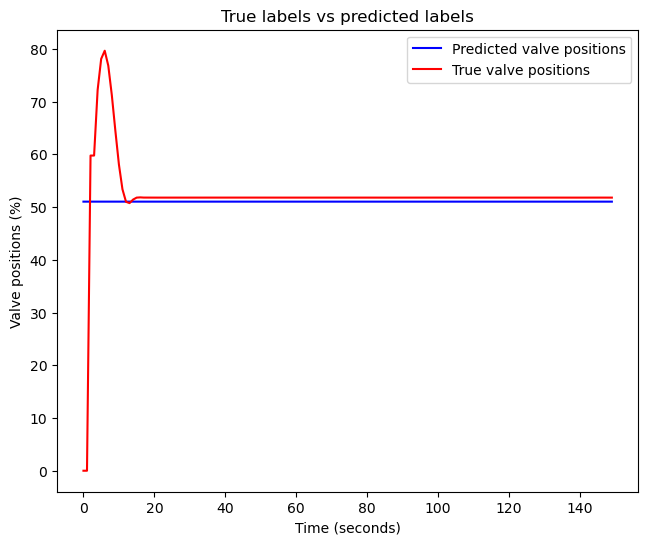

In [191]:
# Plot the predicted and true labels 
fig, ax35 = plt.subplots(figsize = (7.5, 6))
ax35.plot(cat_y7_preds_1[:150], c = 'b', label = "Predicted valve positions")
ax35.plot(y7_test[:150], c = 'r', label = "True valve positions")
ax35.set(xlabel = "Time (seconds)",
         ylabel = "Valve positions (%)",
         title = "True labels vs predicted labels")
ax35.legend();
            
